<a href="https://colab.research.google.com/github/anizamey/week12_lab/blob/main/Lab_Implementing_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing GANs — Hands-on Training of a Simple GAN for Image Generation
---

## Learning objectives

By the end of this lab, you will be able to:

- Explain the **minimax game** between a **generator** $G$ and **discriminator** $D$, and interpret the **value function** used in the original GAN formulation.
- Implement a **vanilla GAN** in PyTorch using **MLPs** on **MNIST** (flattened images).
- Train with **BCE loss**, **Adam**, and **proper label tensors** for real vs. fake samples.
- Visualize **generated samples** and **loss curves**, and connect trends to **training stability**.
- Apply practical **stabilization ideas** (e.g., weight initialization, label smoothing) and **experiment** with architecture and data.

---

## GAN theory (compact refresher)

Generative Adversarial Networks (Goodfellow et al., 2014) frame generation as a **two-player game**:

- **Generator** $G(z)$ maps random noise $z \sim p_z$ (e.g., Gaussian) to data-like samples (here, fake MNIST digits).
- **Discriminator** $D(x)$ outputs a **probability** that input $x$ is **real** (from the dataset) rather than **fake** (from $G$).

**Value function (vanilla GAN, conceptual):**

$$\min_G \max_D \; V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- $D$ tries to **maximize** $\log D(x)$ on real data and **minimize** $D(G(z))$ on fakes (equivalently maximize $\log(1-D(G(z)))$).
- $G$ tries to **fool** $D$, minimizing $\log(1-D(G(z)))$, often implemented by minimizing $-\log(D(G(z)))$ (**non-saturating** generator objective) for stronger gradients when $D$ is confident.

In this lab we use **binary cross-entropy** (`BCELoss`) with **target 1** for real and **target 0** for fake when training $D$; for $G$ we use fake samples with target **1** ("want discriminator to think fake is real").

---

## Prerequisites

- Comfortable with **PyTorch** basics: `nn.Module`, `optim`, tensors, `device` placement.
- Understanding of **binary classification** and **sigmoid + BCE**.
- Familiarity with **MNIST** / image tensors (optional: convolutional GANs are *not* required here — we use **MLPs** on **flattened** images).

## Environment

- **Google Colab** or local **Jupyter** with **PyTorch** + **torchvision** + **matplotlib** + **numpy**.
- Enable **GPU** in Colab (**Runtime → Change runtime type → GPU**) for faster training; the notebook runs on **CPU** as well, only slower.

> Run cells **in order** the first time through.


---

# Tutorial: Step-by-Step Implementation of a Vanilla GAN

This section walks you from **data** → **models** → **training** → **visualization**. Read the markdown between code cells: it explains *what* each block does and *why*.


### Setup: imports, reproducibility, and device

We fix **random seeds** for reproducibility (results may still vary slightly across hardware). **`torch.cuda.is_available()`** selects **GPU** when present.


In [1]:
# Cell: imports, seed, device
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


**What you should see:** a one-line print with `cuda` (GPU) or `cpu`. All later tensors and models will be moved to this `device`.


### Data: MNIST, flattened and scaled to [-1, 1]

- **`ToTensor()`** gives floats in **[0, 1]**.
- We **flatten** to 784-D vectors with **`Lambda`**.
- **GANs** often use **Tanh** outputs; matching the data range to **[-1, 1]** works well: `x' = 2x - 1`.

**Batch size** is **128** as specified.


In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # flatten to 784
    transforms.Lambda(lambda x: 2.0 * x - 1.0),  # [0,1] -> [-1,1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"MNIST train samples: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.22MB/s]

MNIST train samples: 60000
Batches per epoch: 468


**Takeaway:** each batch has shape **`(128, 784)`** after flattening. Discriminator sees **vectors**; this is a **vanilla MLP GAN**, not DCGAN.


### Models: MLP Generator and Discriminator

**Generator:** noise dimension **`nz = 100`**. Hidden layers use **LeakyReLU** (small slope for negative inputs helps gradients). Output is **784** with **Tanh** so outputs lie in **[-1, 1]** (matching images).

**Discriminator:** maps **784 → 1** with **Sigmoid** (probability "real").

**Weight initialization:** small Gaussian noise for weights; zeros for biases — a common starting point (you may compare with default init in the exercises).


In [3]:
nz = 100  # noise dimension

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self, nz: int = 100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nz, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


G = Generator(nz).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

print(G)
print(D)


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


**Sanity check:** parameter counts should be modest (MLPs on 784-D). If shapes mismatch later, re-check **784** and **`nz`**.


### Loss and optimizers

- **`BCELoss`** matches **sigmoid** outputs.
- **Adam** with **`lr=2e-4`**, **`betas=(0.5, 0.999)`** — **beta1 = 0.5** is a common heuristic for GANs (less momentum than default 0.9).

**Labels:** real batch → **1**, fake batch → **0** when training **D**; for **G**, we pass **fakes** with target **1**.


In [4]:
criterion = nn.BCELoss()
lr = 0.0002
betas = (0.5, 0.999)

optimizerD = optim.Adam(D.parameters(), lr=lr, betas=betas)
optimizerG = optim.Adam(G.parameters(), lr=lr, betas=betas)


Separate optimizers let us update **D** and **G** on **different** objectives while sharing the same hyperparameters unless you choose otherwise in the exercises.


### Visualization helpers

We will plot **64** generated digits in an **8×8** grid and track **mean** generator/discriminator loss per epoch.


In [5]:
def denormalize_to_01(x: torch.Tensor) -> torch.Tensor:
    """Map from [-1, 1] back to [0, 1] for plotting."""
    return (x + 1.0) / 2.0


The training loop below uses **`torch.no_grad()`** when rendering snapshots so we **do not** build computation graphs for visualization-only forwards.


### Training loop (50 epochs)

Each epoch:

1. **Update D:** classify real vs fake.
2. **Update G:** maximize $\log D(G(z))$ via **fake labeled as real**.

We log **mean losses** per epoch. Every **5 epochs** we show samples and plot **loss curves so far**.

**Stability tips (commented in code):** balanced updates, **detach** fake tensors when training **D**, optional mild **label smoothing** on real labels for **D** only (see comments — default off for baseline clarity).


Epoch [01/50]  Loss_G: 2.0315  Loss_D: 0.3659


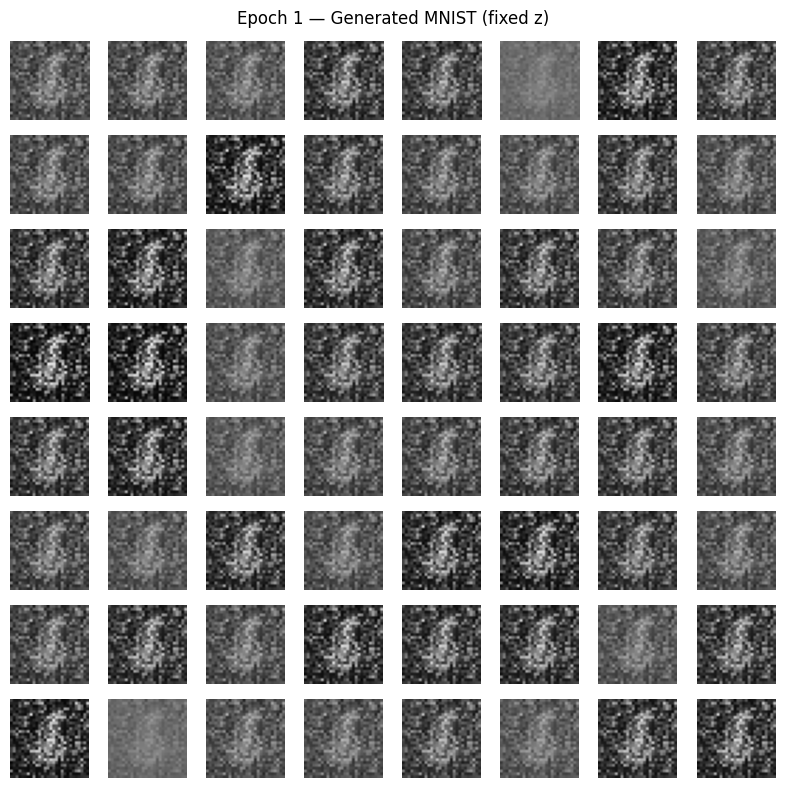

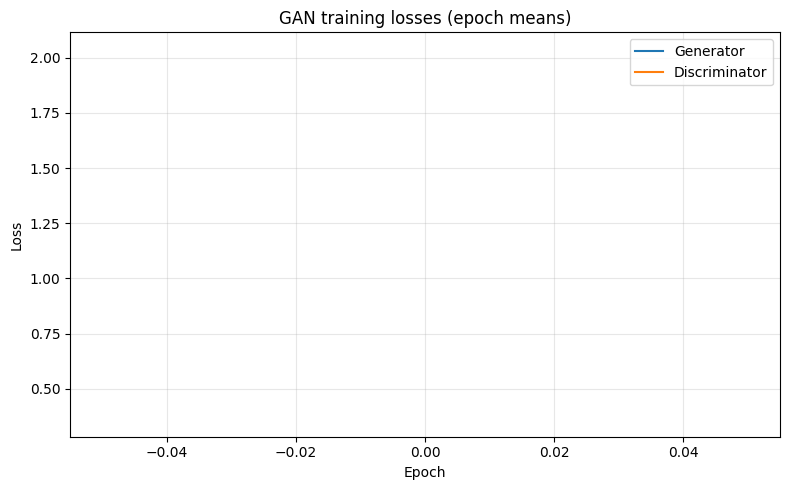

Epoch [02/50]  Loss_G: 4.0056  Loss_D: 0.2403
Epoch [03/50]  Loss_G: 3.4728  Loss_D: 0.2382
Epoch [04/50]  Loss_G: 3.7377  Loss_D: 0.1917
Epoch [05/50]  Loss_G: 3.6933  Loss_D: 0.1453


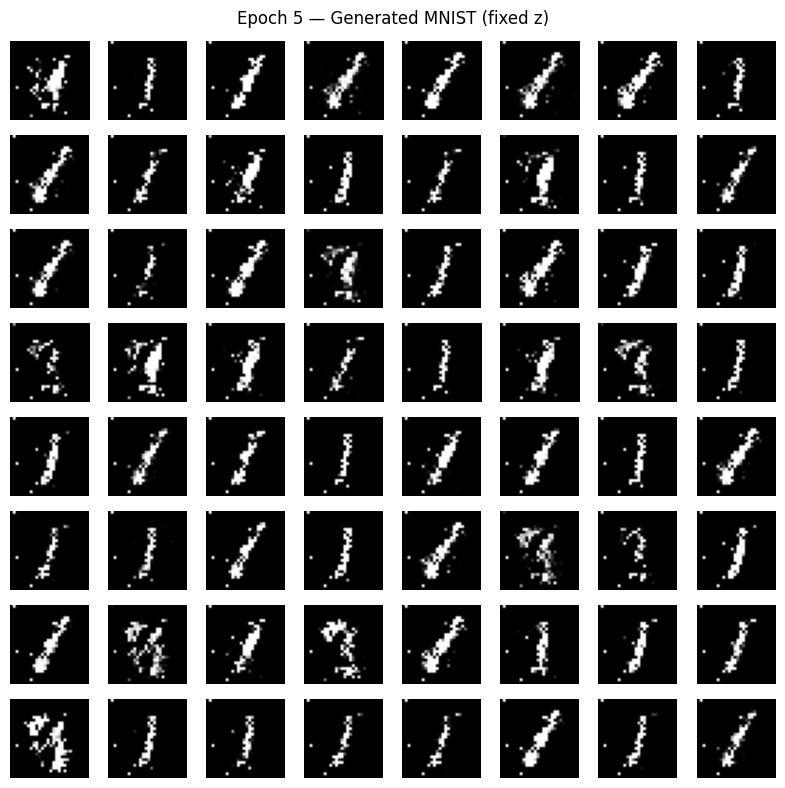

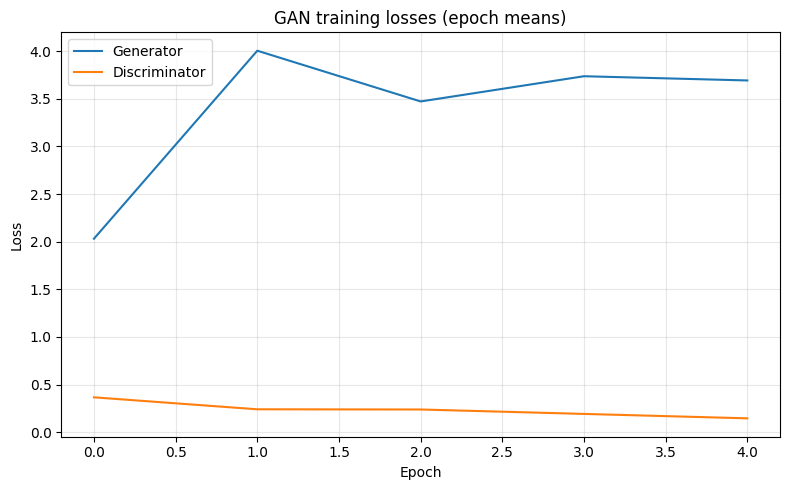

Epoch [06/50]  Loss_G: 3.9369  Loss_D: 0.1279
Epoch [07/50]  Loss_G: 3.8790  Loss_D: 0.1468
Epoch [08/50]  Loss_G: 3.6907  Loss_D: 0.1328
Epoch [09/50]  Loss_G: 3.2307  Loss_D: 0.1655
Epoch [10/50]  Loss_G: 2.8038  Loss_D: 0.2047


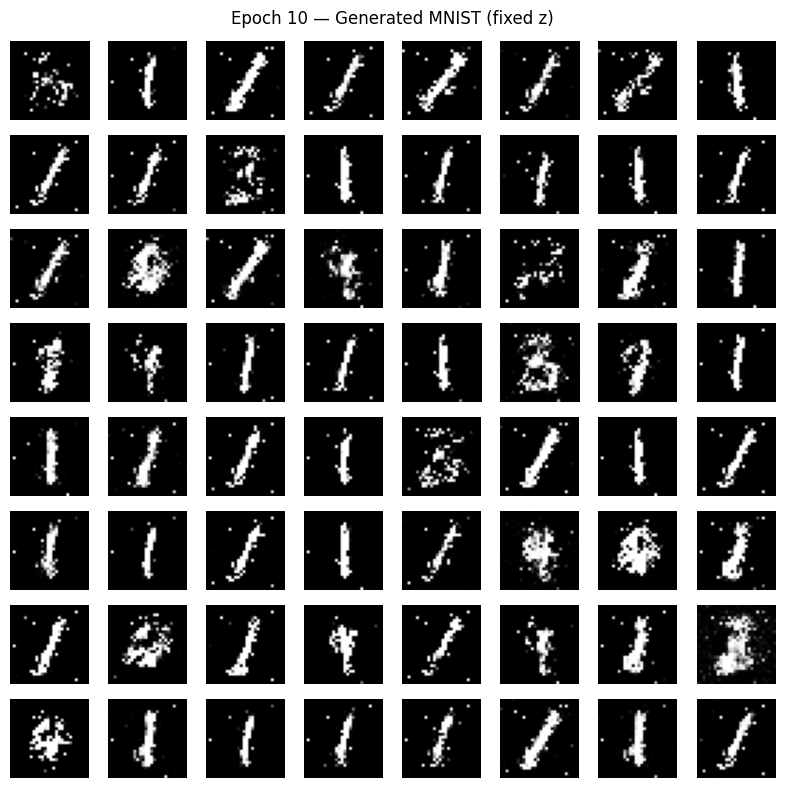

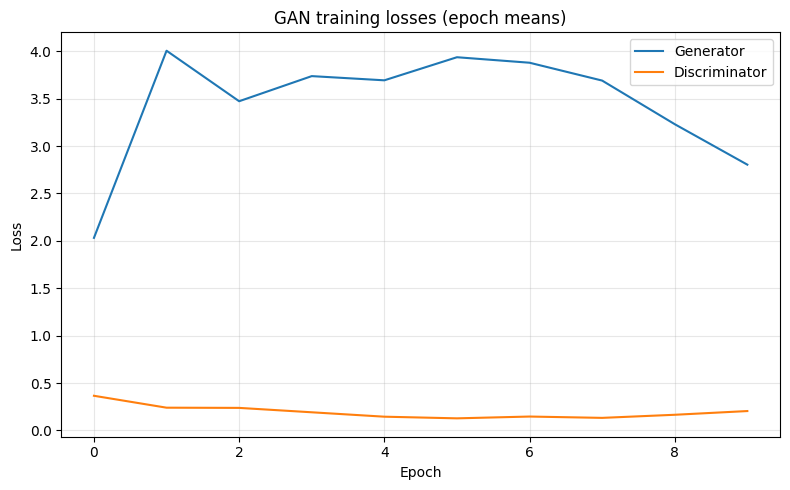

Epoch [11/50]  Loss_G: 2.3523  Loss_D: 0.2964
Epoch [12/50]  Loss_G: 2.0340  Loss_D: 0.3390
Epoch [13/50]  Loss_G: 1.8829  Loss_D: 0.3637
Epoch [14/50]  Loss_G: 1.8093  Loss_D: 0.3794
Epoch [15/50]  Loss_G: 1.8384  Loss_D: 0.3759


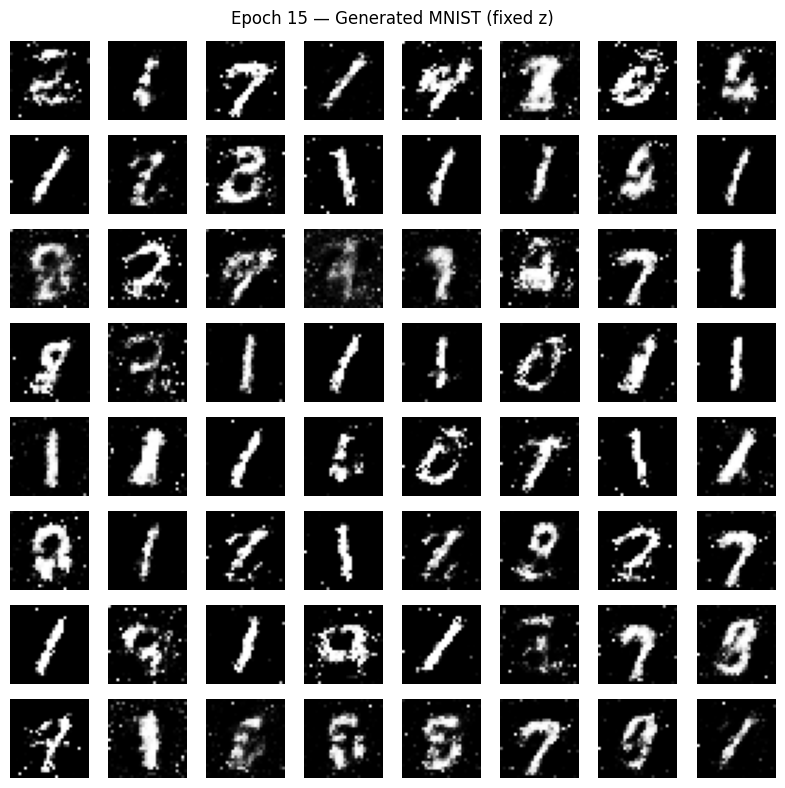

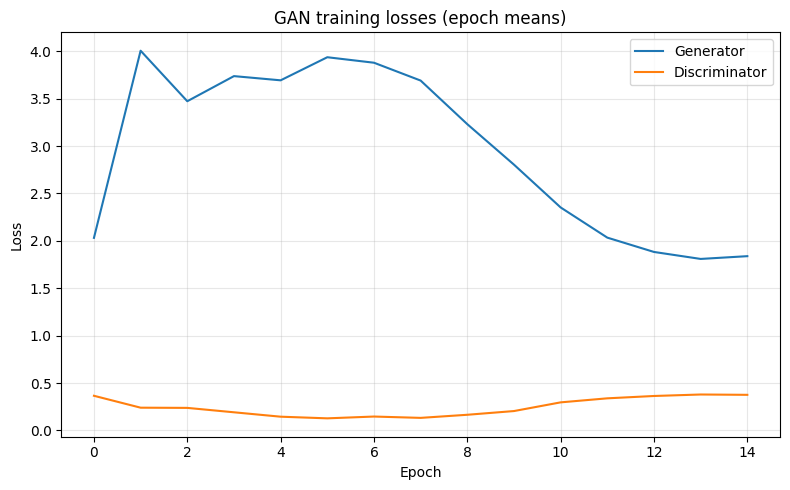

Epoch [16/50]  Loss_G: 1.8195  Loss_D: 0.3831
Epoch [17/50]  Loss_G: 1.8038  Loss_D: 0.3853
Epoch [18/50]  Loss_G: 1.7742  Loss_D: 0.3907
Epoch [19/50]  Loss_G: 1.7395  Loss_D: 0.4000
Epoch [20/50]  Loss_G: 1.8028  Loss_D: 0.3830


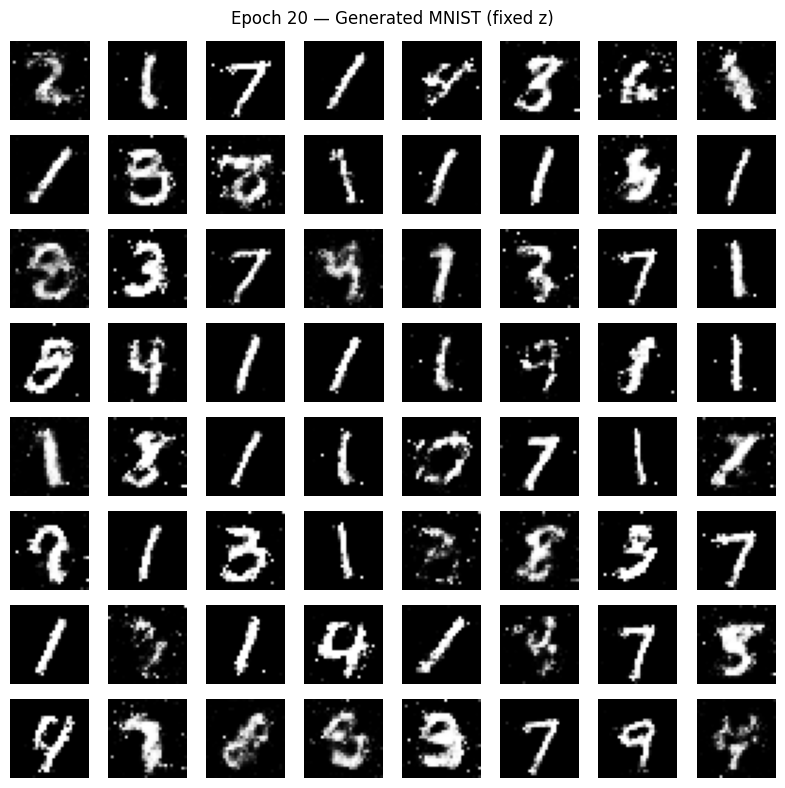

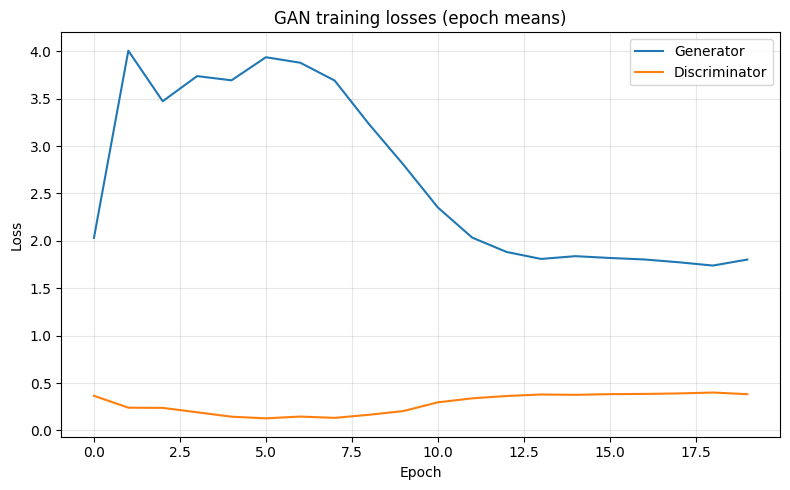

Epoch [21/50]  Loss_G: 1.8386  Loss_D: 0.3747
Epoch [22/50]  Loss_G: 1.8561  Loss_D: 0.3718
Epoch [23/50]  Loss_G: 1.8653  Loss_D: 0.3624
Epoch [24/50]  Loss_G: 1.8495  Loss_D: 0.3689
Epoch [25/50]  Loss_G: 1.8531  Loss_D: 0.3652


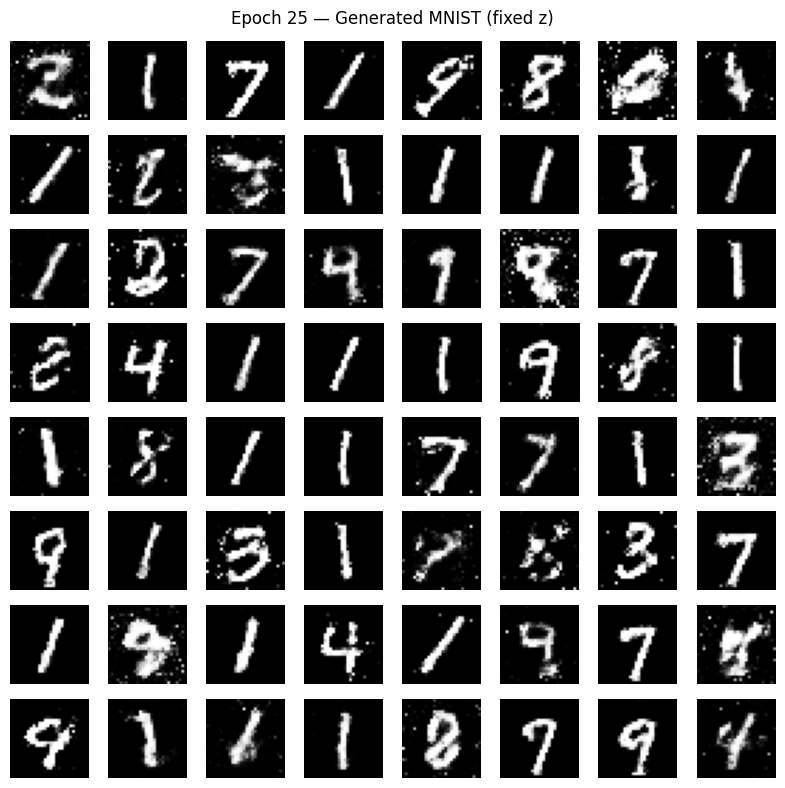

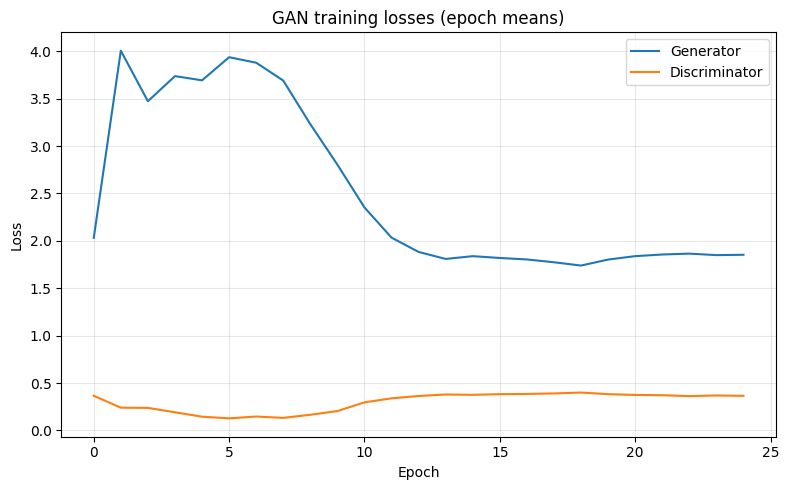

Epoch [26/50]  Loss_G: 1.8599  Loss_D: 0.3650
Epoch [27/50]  Loss_G: 1.8412  Loss_D: 0.3659
Epoch [28/50]  Loss_G: 1.8462  Loss_D: 0.3648
Epoch [29/50]  Loss_G: 1.8445  Loss_D: 0.3621
Epoch [30/50]  Loss_G: 1.8427  Loss_D: 0.3638


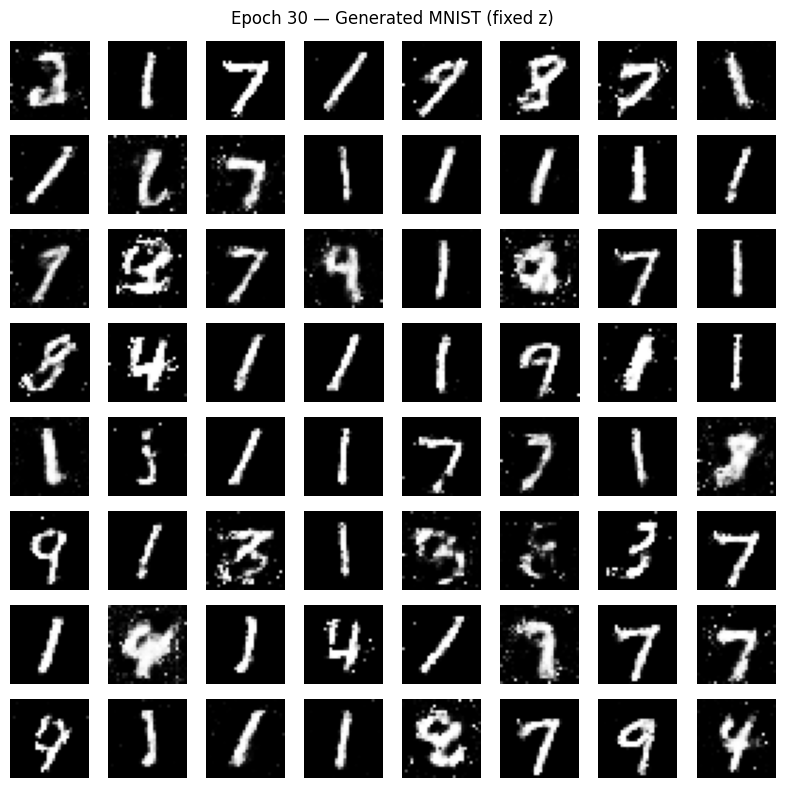

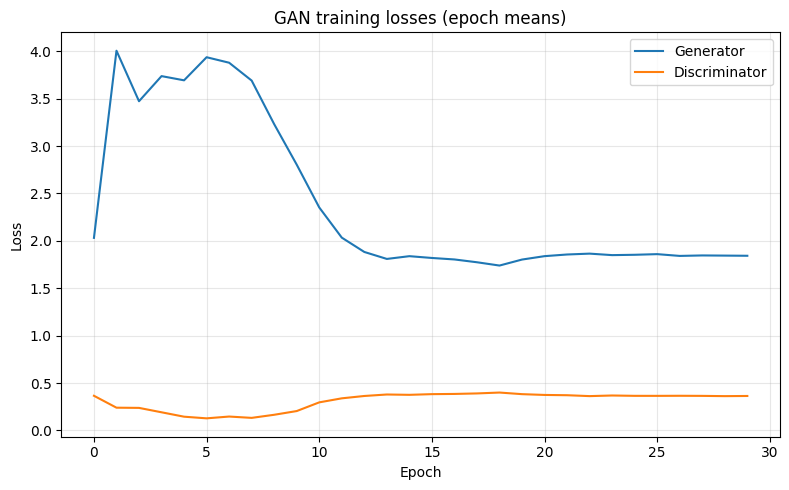

Epoch [31/50]  Loss_G: 1.8384  Loss_D: 0.3606
Epoch [32/50]  Loss_G: 1.8465  Loss_D: 0.3578
Epoch [33/50]  Loss_G: 1.8518  Loss_D: 0.3575
Epoch [34/50]  Loss_G: 1.8619  Loss_D: 0.3539
Epoch [35/50]  Loss_G: 1.8546  Loss_D: 0.3523


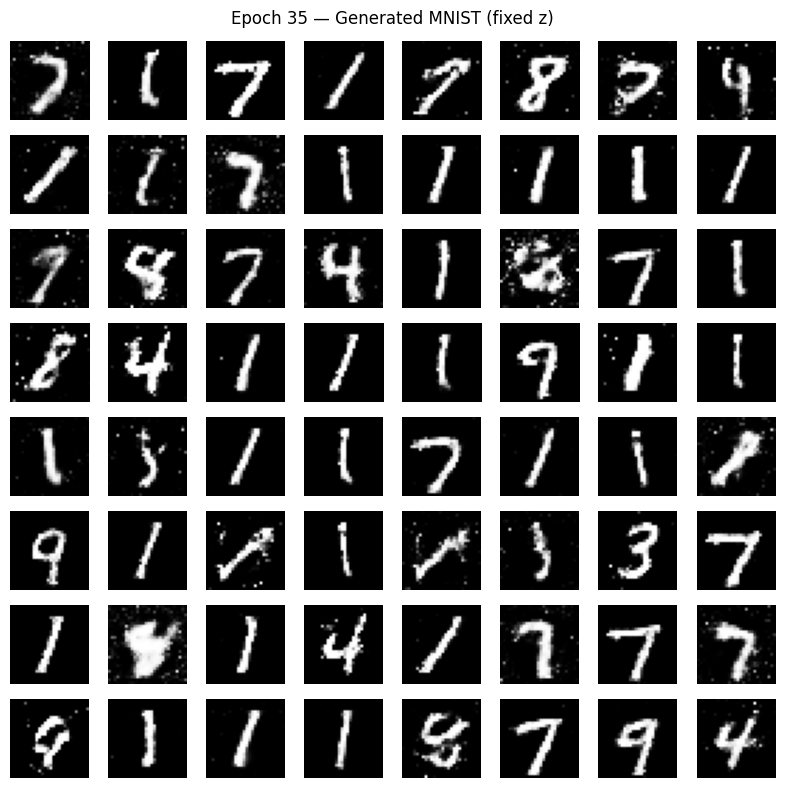

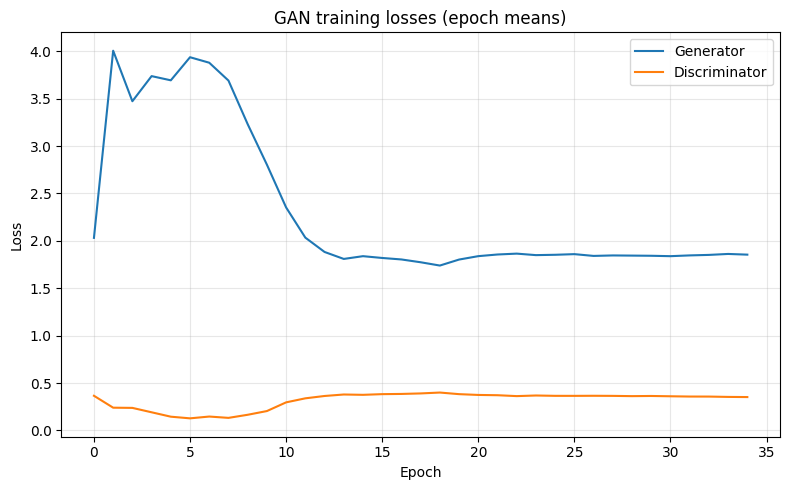

Epoch [36/50]  Loss_G: 1.8516  Loss_D: 0.3544
Epoch [37/50]  Loss_G: 1.8302  Loss_D: 0.3550
Epoch [38/50]  Loss_G: 1.8434  Loss_D: 0.3499
Epoch [39/50]  Loss_G: 1.8361  Loss_D: 0.3545
Epoch [40/50]  Loss_G: 1.8304  Loss_D: 0.3542


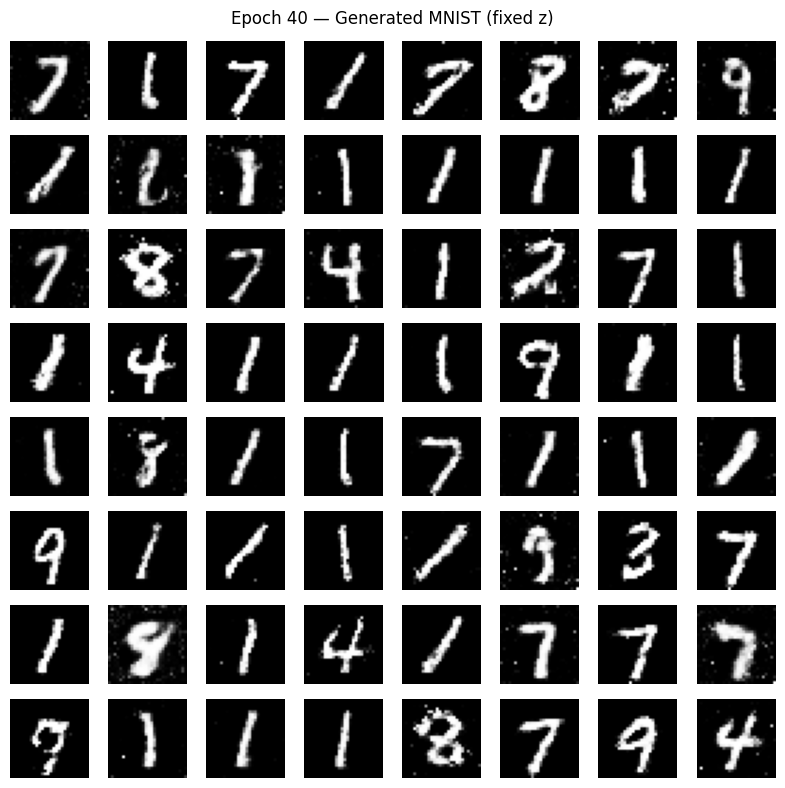

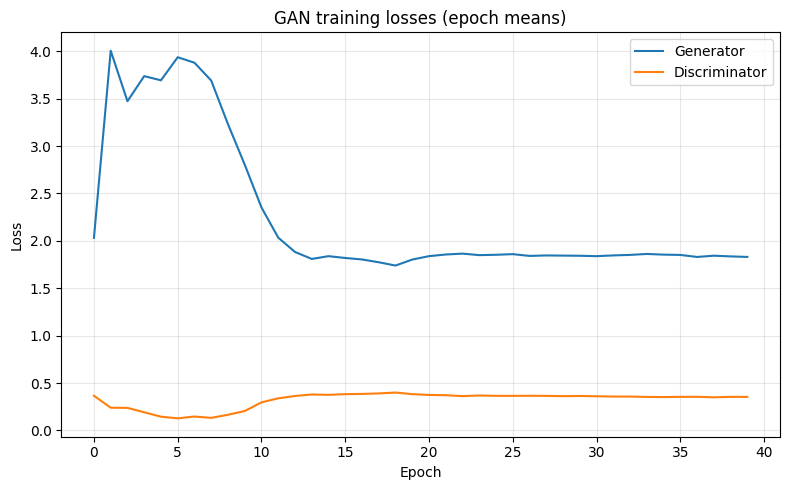

Epoch [41/50]  Loss_G: 1.8113  Loss_D: 0.3558
Epoch [42/50]  Loss_G: 1.8131  Loss_D: 0.3566
Epoch [43/50]  Loss_G: 1.8137  Loss_D: 0.3556
Epoch [44/50]  Loss_G: 1.8137  Loss_D: 0.3559
Epoch [45/50]  Loss_G: 1.7979  Loss_D: 0.3554


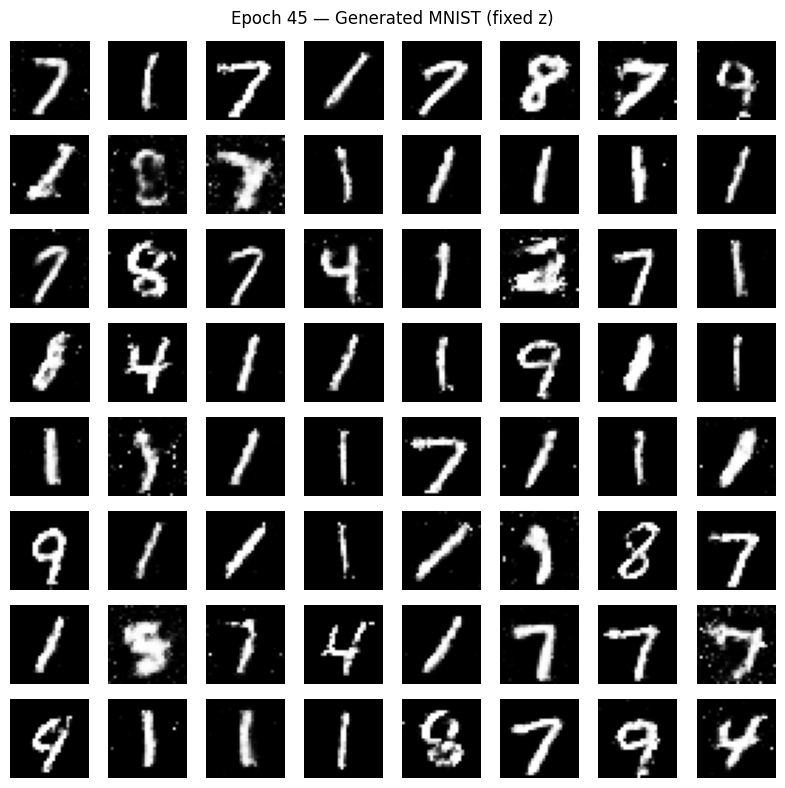

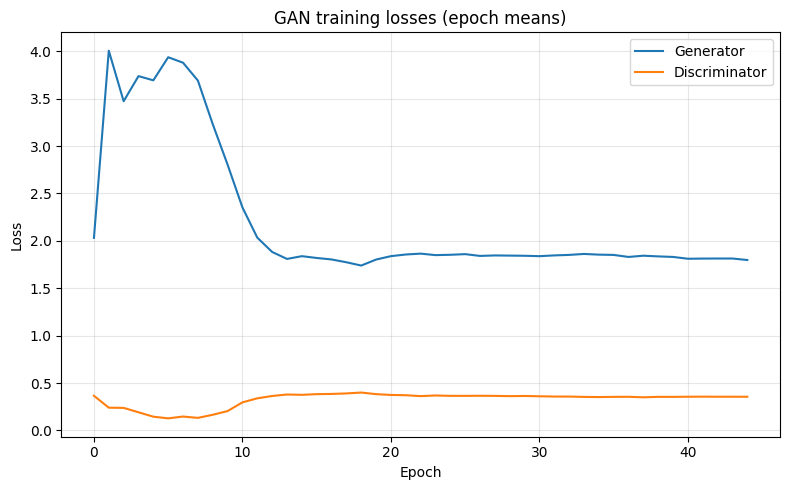

Epoch [46/50]  Loss_G: 1.8027  Loss_D: 0.3570
Epoch [47/50]  Loss_G: 1.7933  Loss_D: 0.3589
Epoch [48/50]  Loss_G: 1.7907  Loss_D: 0.3550
Epoch [49/50]  Loss_G: 1.7954  Loss_D: 0.3552
Epoch [50/50]  Loss_G: 1.7921  Loss_D: 0.3576


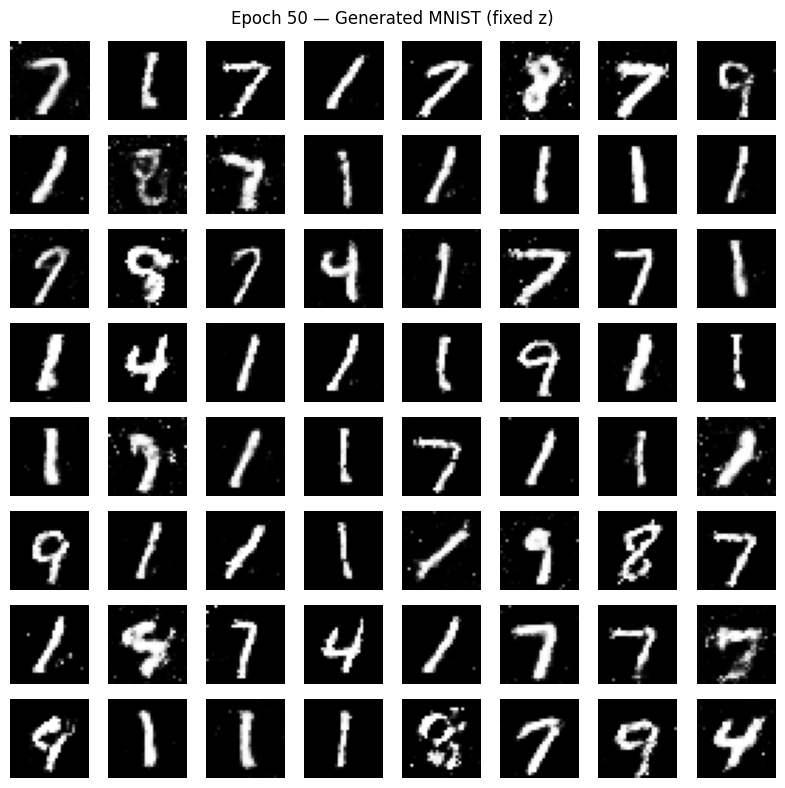

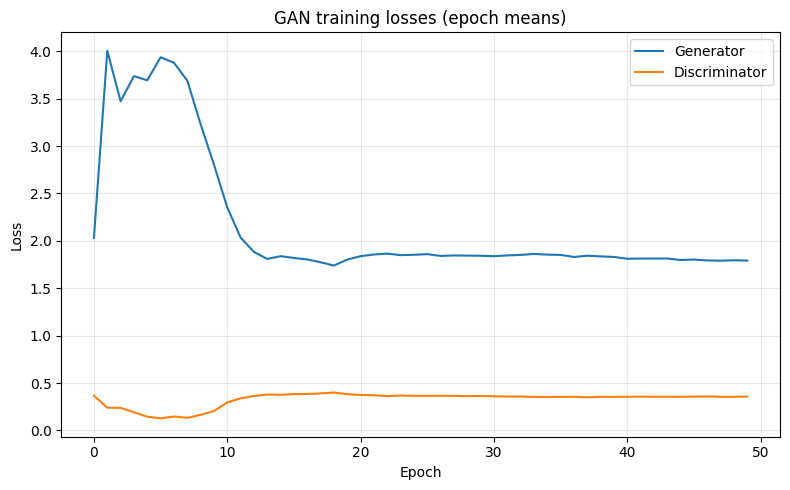

In [6]:
num_epochs = 50

loss_G_hist = []
loss_D_hist = []

fixed_z = torch.randn(64, nz, device=device)  # same noise for comparable snapshots

for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        bsz = real_images.size(0)

        # --- Labels ---
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        # Optional mild label smoothing for real labels (D only) — uncomment to experiment:
        # label_smooth = 0.1
        # real_labels = real_labels * (1.0 - label_smooth) + 0.5 * label_smooth

        # =====================
        # (1) Update Discriminator
        # =====================
        optimizerD.zero_grad(set_to_none=True)

        # Real batch
        out_real = D(real_images)
        loss_real = criterion(out_real, real_labels)

        # Fake batch
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z).detach()
        out_fake = D(fake_images)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = (loss_real + loss_fake) / 2.0
        loss_D.backward()
        optimizerD.step()

        # =====================
        # (2) Update Generator
        # =====================
        optimizerG.zero_grad(set_to_none=True)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z)
        out_fake_for_G = D(fake_images)
        loss_G = criterion(out_fake_for_G, real_labels)  # want D(fake) ~ 1
        loss_G.backward()
        optimizerG.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1

    loss_G_hist.append(epoch_g_loss / num_batches)
    loss_D_hist.append(epoch_d_loss / num_batches)

    print(f"Epoch [{epoch:02d}/{num_epochs}]  Loss_G: {loss_G_hist[-1]:.4f}  Loss_D: {loss_D_hist[-1]:.4f}")

    if epoch % 5 == 0 or epoch == 1:
        # Snapshot with fixed noise
        G.eval()
        with torch.no_grad():
            fakes = G(fixed_z).cpu().view(64, 28, 28)
            fakes = denormalize_to_01(fakes.clamp(-1, 1))
        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(fakes[i], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch} — Generated MNIST (fixed z)')
        plt.tight_layout()
        plt.show()
        G.train()

        # Loss curves
        plt.figure(figsize=(8, 5))
        plt.plot(loss_G_hist, label='Generator')
        plt.plot(loss_D_hist, label='Discriminator')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('GAN training losses (epoch means)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


### Interpreting results

- Early epochs often show **noisy** or **blurry** digits; later epochs should show **clearer** structure if training succeeds.
- **Loss curves are not like supervised learning:** there is **no single "lower is better"** rule for both curves simultaneously. Large **oscillation** can indicate imbalance between **D** and **G**.
- If **D** becomes too strong too fast, **G** may get **weak gradients** ("vanishing" signal). Remedies include **less frequent D updates**, **noise** to inputs, **architecture** changes, **WGAN**-style objectives (theory section), or **label smoothing**.

---


---

# Lab Exercises (Total: 100 points)

These tasks build on the tutorial code above. Each one asks for **small, concrete changes**—you mostly **copy** the training loop and change **one** setting at a time. Replace the **`pass`** in each code cell with your work (you can also add new cells).

| Task | Topic | Points |
|------|--------|--------|
| 1 | Slightly bigger Generator (one clear change) | 20 |
| 2 | Same GAN on Fashion-MNIST | 15 |
| 3 | Compare **two** learning rates | 35 |
| 4 | Label smoothing (real labels = 0.9) | 30 |
| | **Total** | **100** |


## Task 1 — Slightly bigger Generator (20 points)

**What to do:** Copy the tutorial `Generator` class. Change **only one** thing, for example:

- make the **first** hidden layer wider (e.g. `256` → `512`), **or**
- add **one** extra `Linear` + `LeakyReLU` block **before** the last layer that outputs 784.

Keep the **Discriminator** and **training settings** the same as the tutorial (`Adam`, `lr`, `batch_size`, etc.).

**Hand in:**

1. One or two sentences describing what you changed.
2. Train for **20** epochs if you can.
3. Show **one** 8×8 grid of **your** generated images at the **last** epoch (you may reuse the plotting code from the tutorial).
4. Two or three sentences: Do the samples look **better, worse, or about the same** as the tutorial? Any odd behavior?


**Hint:** Duplicate the tutorial cells in this section or copy the `Generator` + training loop here so you do not break your original MNIST run.


Generator_1(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=2048, out_features=784, bias=True)
    (9): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=256, ou

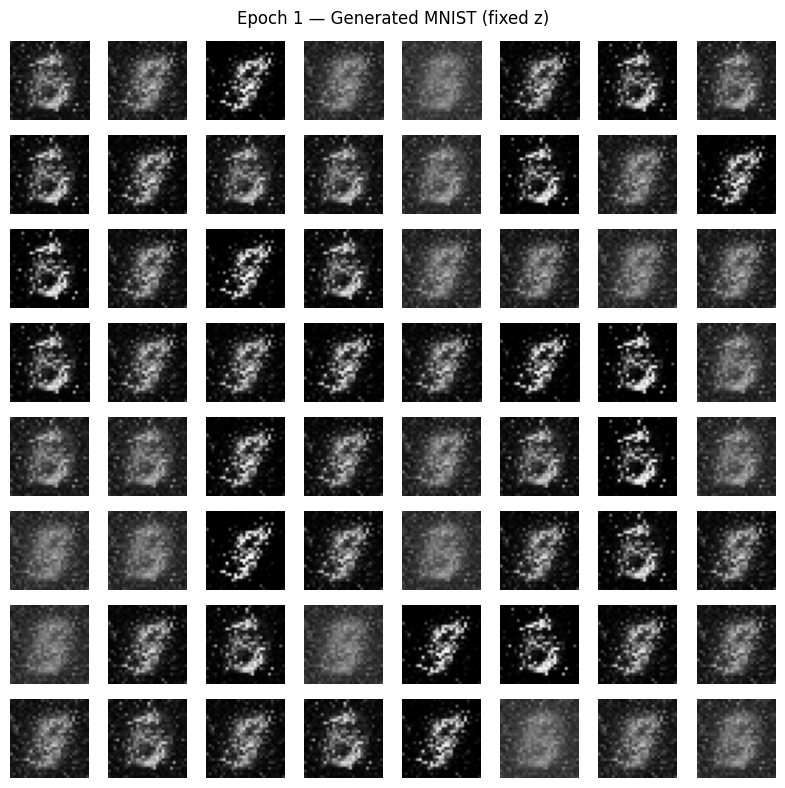

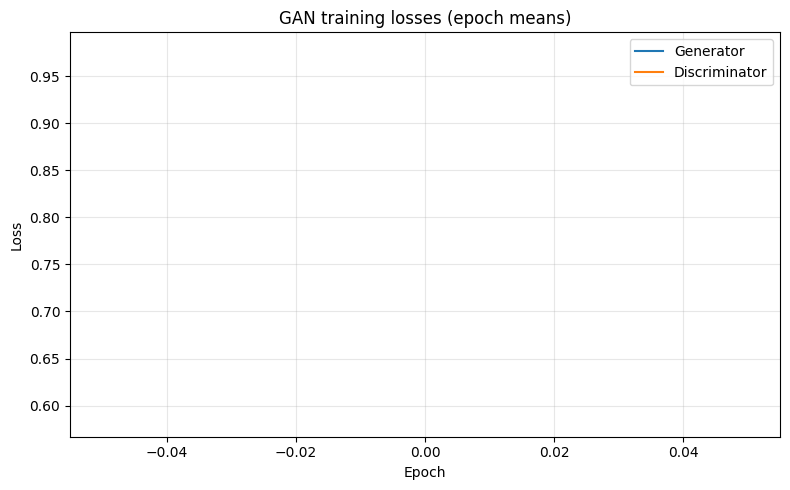

Epoch [02/20]  Loss_G: 1.9443  Loss_D: 0.4667
Epoch [03/20]  Loss_G: 2.2149  Loss_D: 0.4200
Epoch [04/20]  Loss_G: 2.2963  Loss_D: 0.3778
Epoch [05/20]  Loss_G: 2.4657  Loss_D: 0.3440


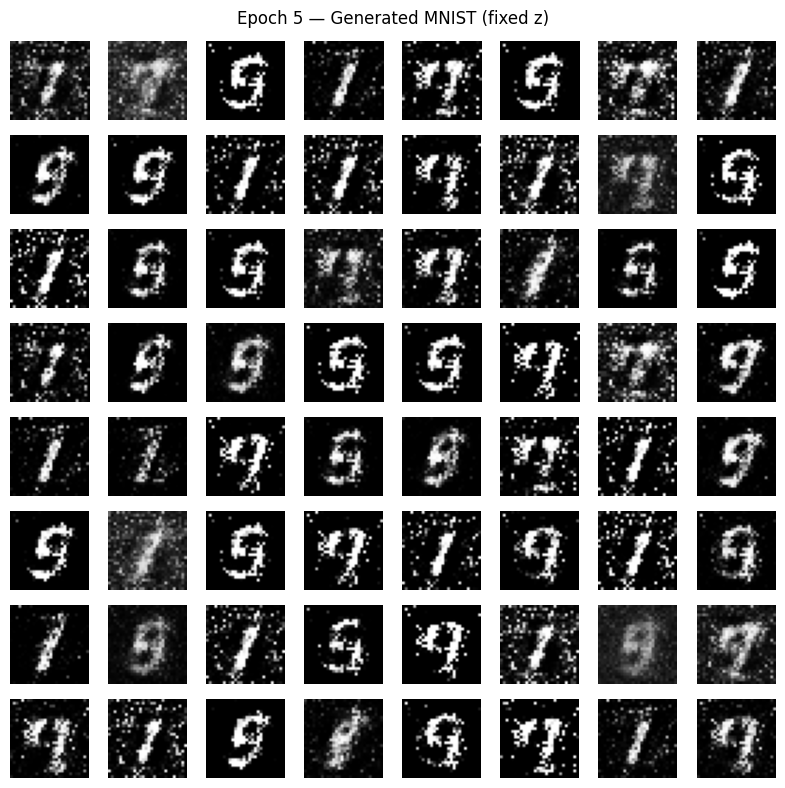

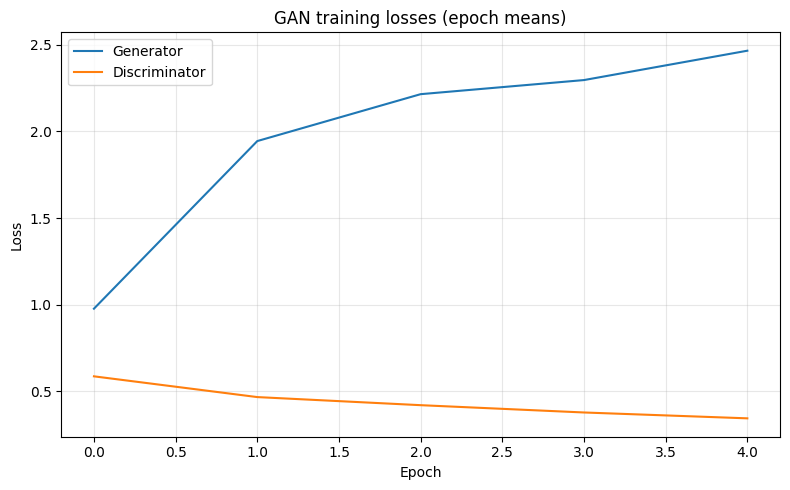

Epoch [06/20]  Loss_G: 2.1757  Loss_D: 0.3701
Epoch [07/20]  Loss_G: 2.2042  Loss_D: 0.3377
Epoch [08/20]  Loss_G: 1.9250  Loss_D: 0.3822
Epoch [09/20]  Loss_G: 1.7824  Loss_D: 0.4176
Epoch [10/20]  Loss_G: 1.5165  Loss_D: 0.4626


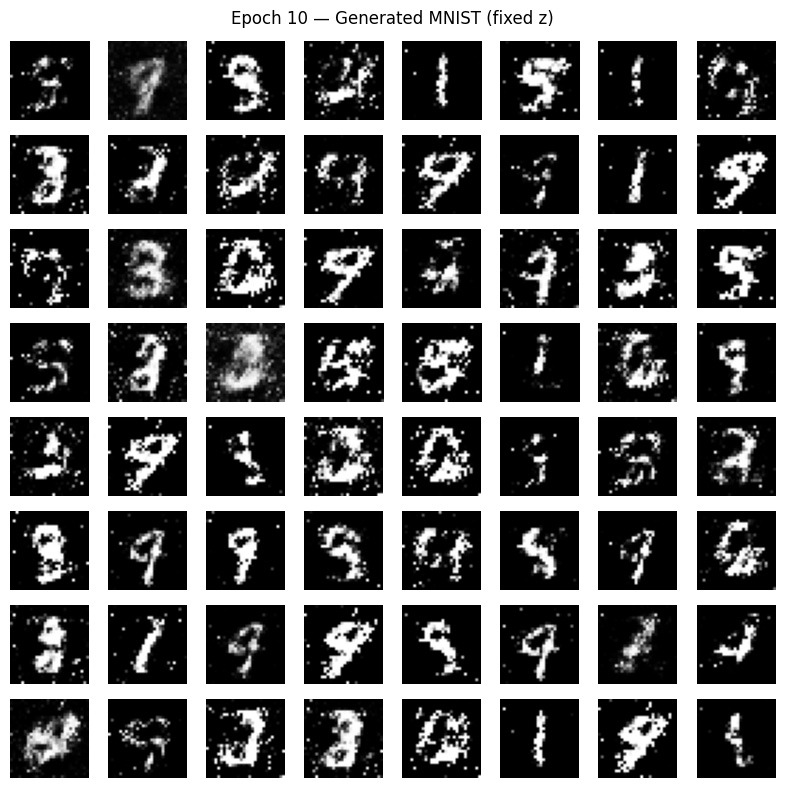

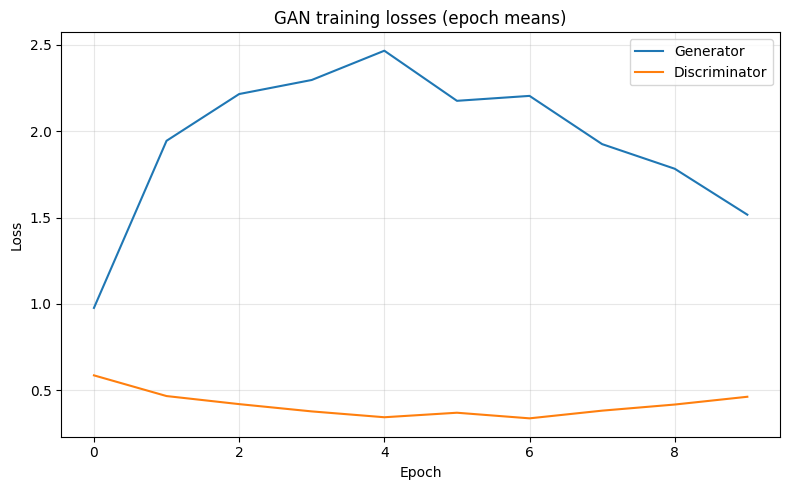

Epoch [11/20]  Loss_G: 1.4728  Loss_D: 0.4784
Epoch [12/20]  Loss_G: 1.3244  Loss_D: 0.5130
Epoch [13/20]  Loss_G: 1.2916  Loss_D: 0.5242
Epoch [14/20]  Loss_G: 1.2871  Loss_D: 0.5292
Epoch [15/20]  Loss_G: 1.2338  Loss_D: 0.5400


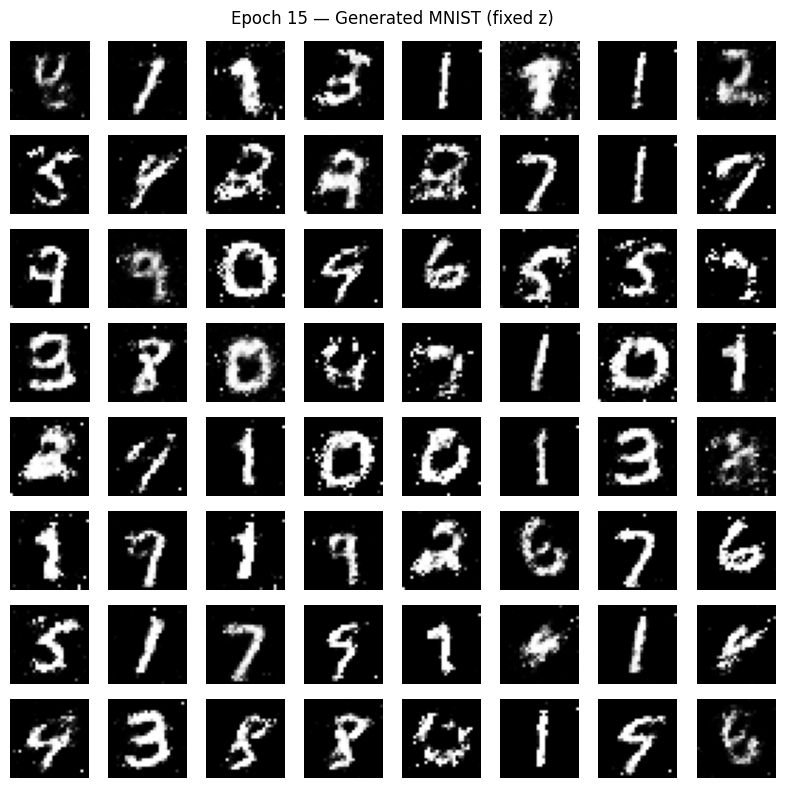

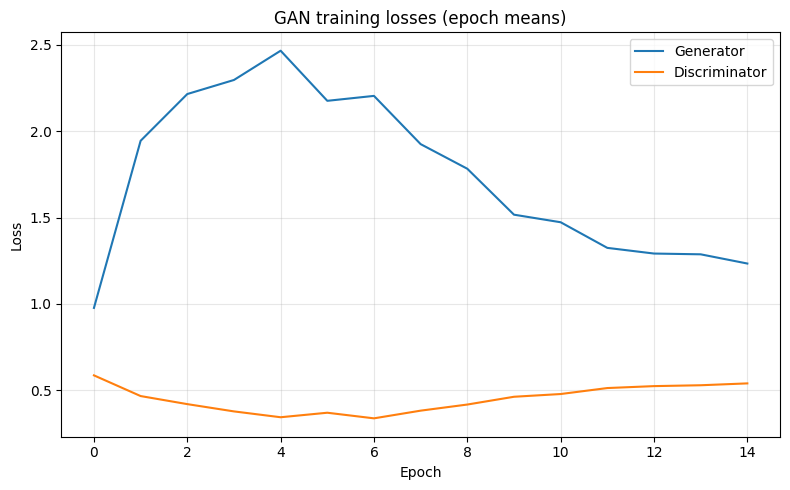

Epoch [16/20]  Loss_G: 1.2429  Loss_D: 0.5398
Epoch [17/20]  Loss_G: 1.2471  Loss_D: 0.5402
Epoch [18/20]  Loss_G: 1.2607  Loss_D: 0.5354
Epoch [19/20]  Loss_G: 1.2459  Loss_D: 0.5383
Epoch [20/20]  Loss_G: 1.2305  Loss_D: 0.5414


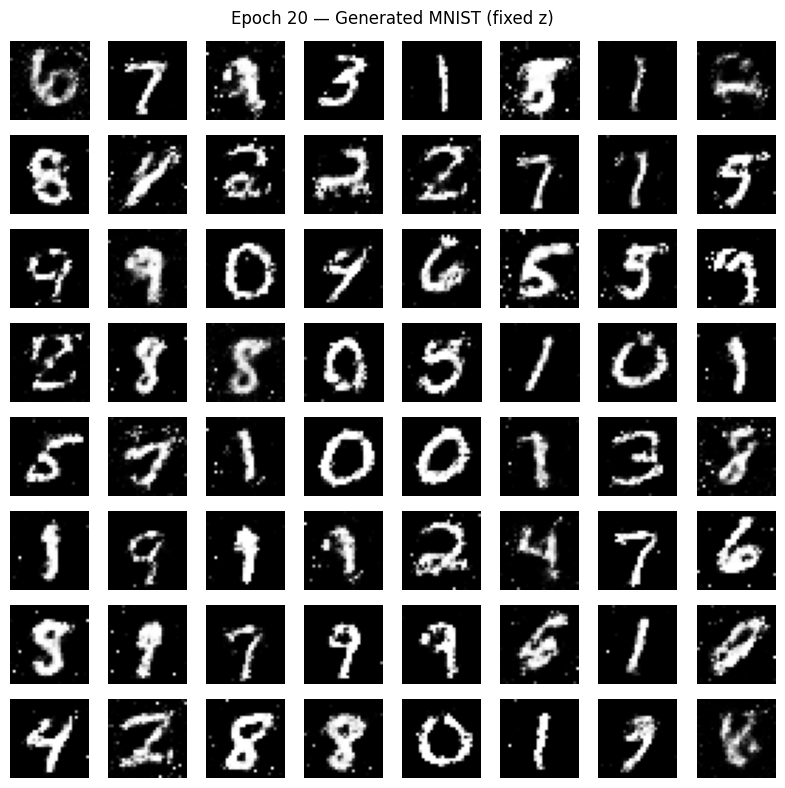

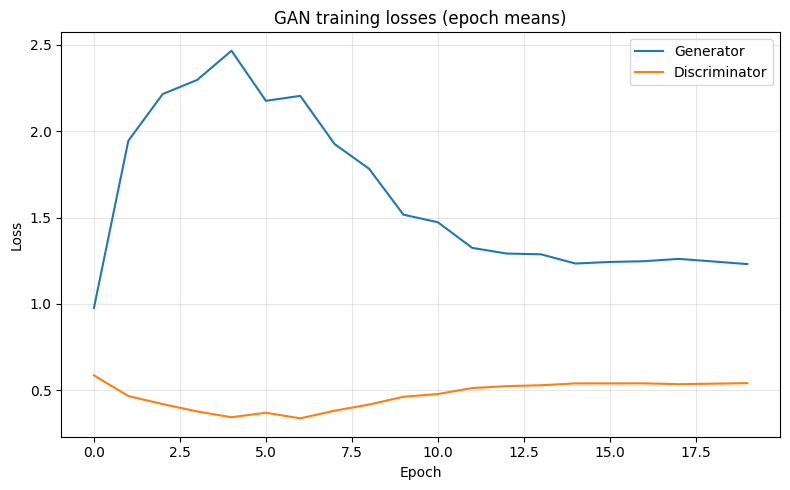

In [11]:
from torch.nn.modules import loss
# TODO Task 1: Paste your modified Generator + training code here (copy from tutorial).
# TODO: Train and show an 8x8 grid of generated images.

class Generator_1(nn.Module):
    def __init__(self, nz: int = 100):
        super().__init__()
        self.net = nn.Sequential(
    nn.Linear(nz, 256),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Linear(256,512),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Linear(512, 1024),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Linear(1024,2048),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Linear(2048, 784),
    nn.Tanh(),
)
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


G_1 = Generator_1(nz).to(device)
D_1 = Discriminator().to(device)
G_1.apply(weights_init)
D_1.apply(weights_init)

# Initialize optimizers for G_1 and D_1
optimizerD_1 = optim.Adam(D_1.parameters(), lr=lr, betas=betas)
optimizerG_1 = optim.Adam(G_1.parameters(), lr=lr, betas=betas)

print(G_1)
print(D_1)

EPOCH=20

loss_G_hist_1 = []
loss_D_hist_1 = []

fixed_z = torch.randn(64, nz, device=device)

for epoch in range(1, EPOCH + 1):
    G_1.train()
    D_1.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        bsz = real_images.size(0)

        # --- Labels ---
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        # =====================
        # (1) Update Discriminator
        # =====================
        optimizerD_1.zero_grad(set_to_none=True)

        # Real batch
        out_real = D_1(real_images)
        loss_real = criterion(out_real, real_labels)

        # Fake batch
        z = torch.randn(bsz, nz, device=device)
        fake_images = G_1(z).detach()
        out_fake = D_1(fake_images)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = (loss_real + loss_fake) / 2.0
        loss_D.backward()
        optimizerD_1.step()

        # =====================
        # (2) Update Generator
        # =====================
        optimizerG_1.zero_grad(set_to_none=True)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G_1(z)
        out_fake_for_G = D_1(fake_images)
        loss_G = criterion(out_fake_for_G, real_labels)  # want D(fake) ~ 1
        loss_G.backward()
        optimizerG_1.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1

    loss_G_hist_1.append(epoch_g_loss / num_batches)
    loss_D_hist_1.append(epoch_d_loss / num_batches)

    print(f"Epoch [{epoch:02d}/{EPOCH}]  Loss_G: {loss_G_hist_1[-1]:.4f}  Loss_D: {loss_D_hist_1[-1]:.4f}")

    if epoch % 5 == 0 or epoch == 1:
        # Snapshot with fixed noise
        G_1.eval()
        with torch.no_grad():
            fakes = G_1(fixed_z).cpu().view(64, 28, 28)
            fakes = denormalize_to_01(fakes.clamp(-1, 1))
        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(fakes[i], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch} — Generated MNIST (fixed z)')
        plt.tight_layout()
        plt.show()
        G_1.train()

        # Loss curves
        plt.figure(figsize=(8, 5))
        plt.plot(loss_G_hist_1, label='Generator')
        plt.plot(loss_D_hist_1, label='Discriminator')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('GAN training losses (epoch means)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


Well its result with extra layer shows recognasible shapes, howefewer its results are still a litle blury and has noisy problem with 8 and 9 digits. But comparing to 20th epoch trained in tutorial, it signifacantly improved.

**Grading (20 pts):** Clear one-line change + trained model + image grid + short comment.




## Task 2 — Fashion-MNIST (15 points)

**What to do:** Use **Fashion-MNIST** instead of MNIST. In `torchvision`, load `datasets.FashionMNIST` with the **same** `transform` as in the tutorial (flatten + scale to [-1, 1]). Keep the same `Generator`, `Discriminator`, and training code.

**Hand in:**

1. One small grid (e.g. 8×8) of **real** Fashion-MNIST images so we see the dataset.
2. One grid of **fake** images after training (**at least 25 epochs**; use 50 if you can).
3. Two sentences: Does your generator produce **recognizable** clothes/shoes, or mostly **blur/noise**? How does that compare to digits?


**Tip:** Create **new** variables (e.g. `train_loader_fashion`, `G_f`, `D_f`) so you do not overwrite the MNIST models.


100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.4MB/s]


Fashion train sample: 60000
Fashion train loader: 468
Epoch [01/25]  Loss_G: 2.6087  Loss_D: 0.3019


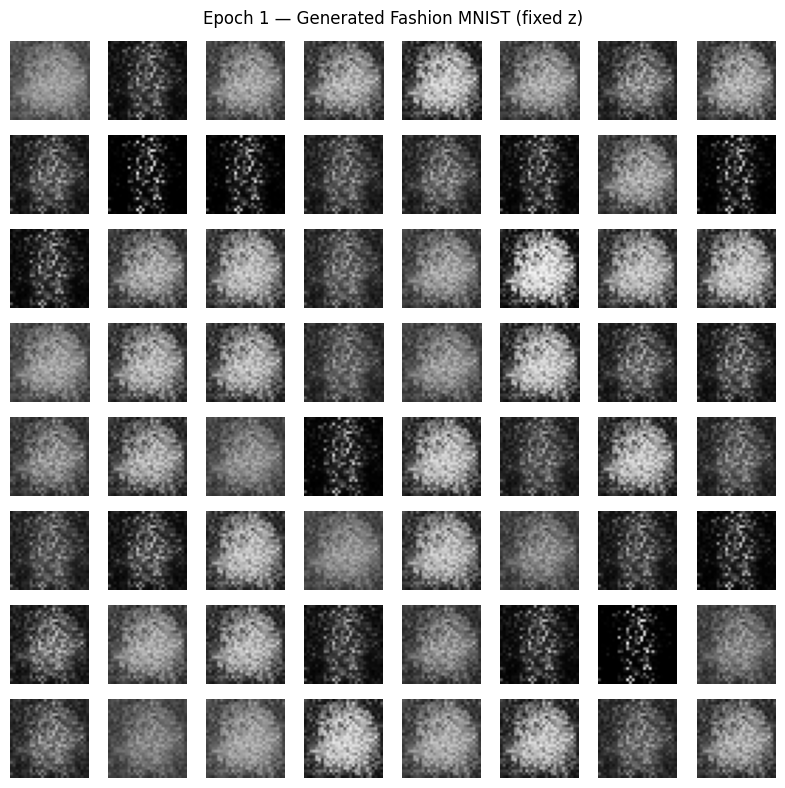

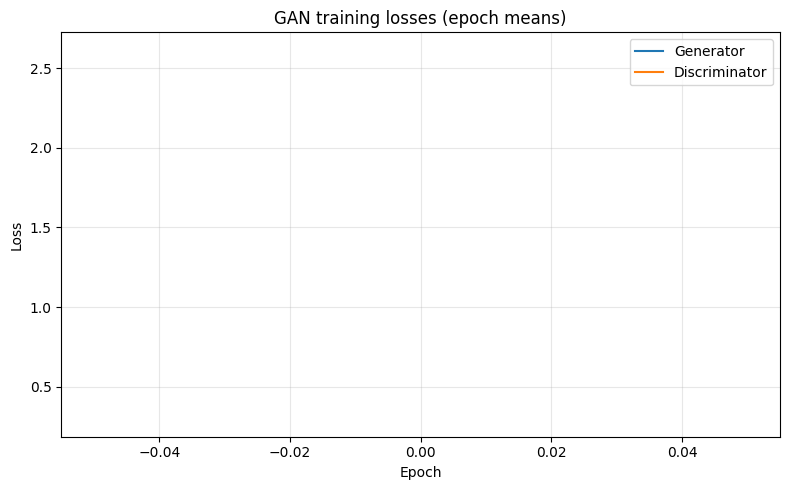

Epoch [02/25]  Loss_G: 3.1238  Loss_D: 0.3245
Epoch [03/25]  Loss_G: 2.5442  Loss_D: 0.3621
Epoch [04/25]  Loss_G: 2.1293  Loss_D: 0.4053
Epoch [05/25]  Loss_G: 1.9981  Loss_D: 0.4309


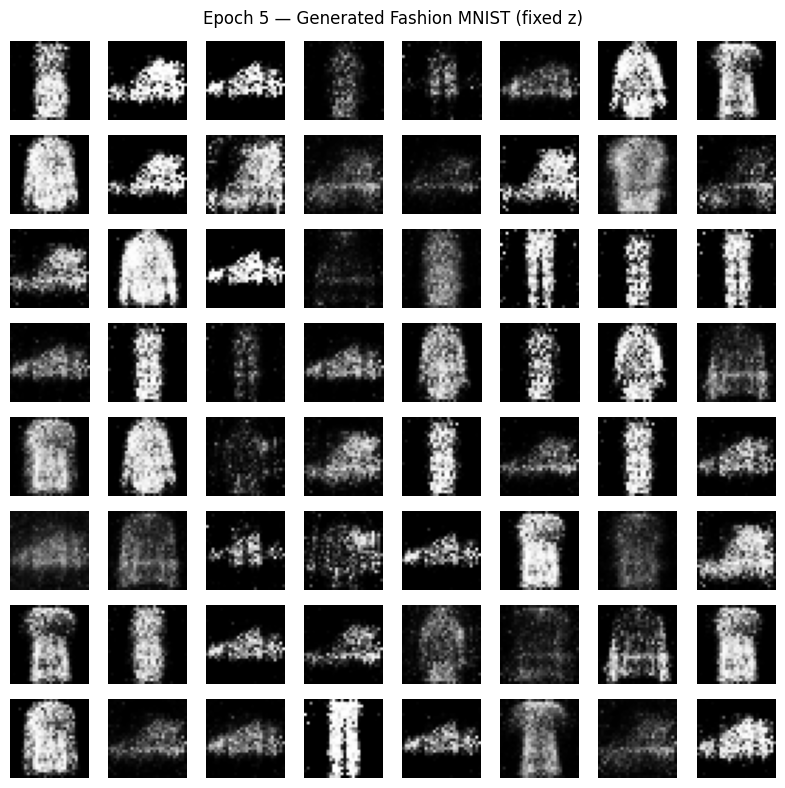

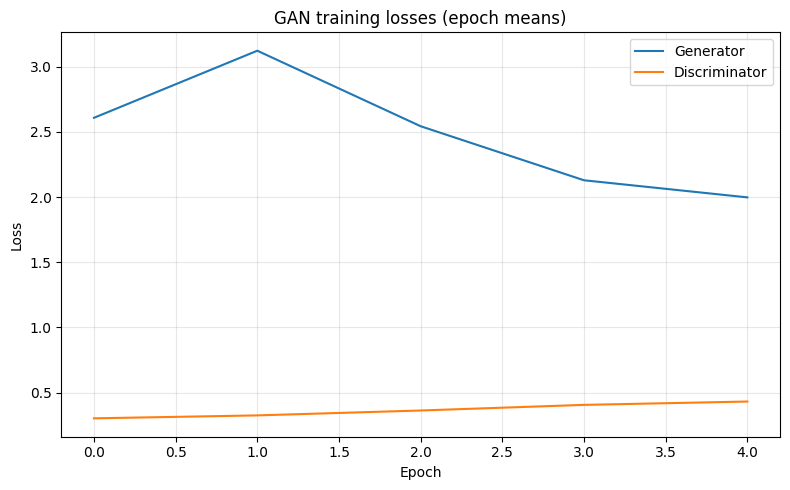

Epoch [06/25]  Loss_G: 1.8598  Loss_D: 0.4531
Epoch [07/25]  Loss_G: 1.7481  Loss_D: 0.4668
Epoch [08/25]  Loss_G: 1.6500  Loss_D: 0.4868
Epoch [09/25]  Loss_G: 1.6144  Loss_D: 0.4906
Epoch [10/25]  Loss_G: 1.5531  Loss_D: 0.4963


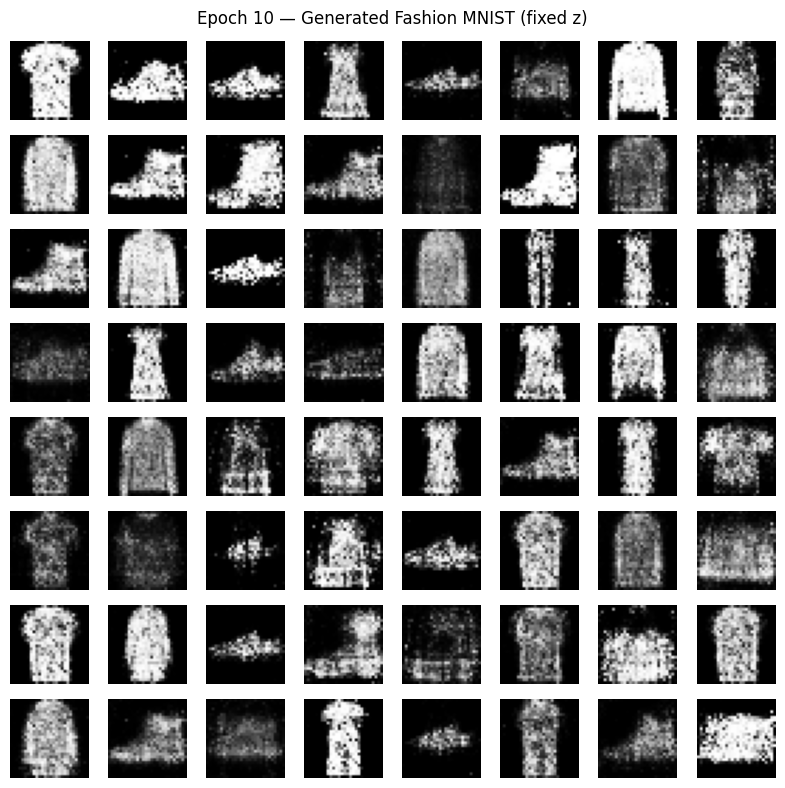

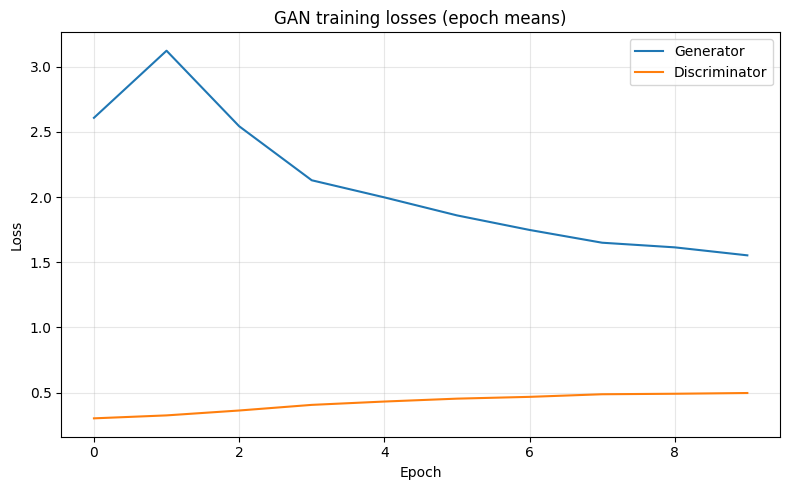

Epoch [11/25]  Loss_G: 1.5156  Loss_D: 0.4978
Epoch [12/25]  Loss_G: 1.4820  Loss_D: 0.5019
Epoch [13/25]  Loss_G: 1.4413  Loss_D: 0.5101
Epoch [14/25]  Loss_G: 1.4029  Loss_D: 0.5173
Epoch [15/25]  Loss_G: 1.3606  Loss_D: 0.5285


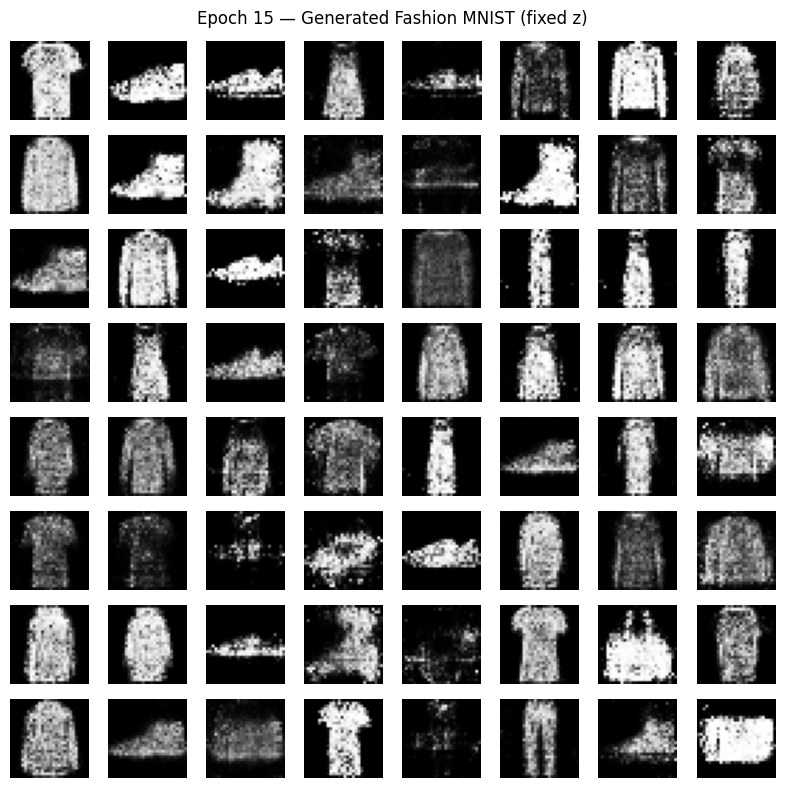

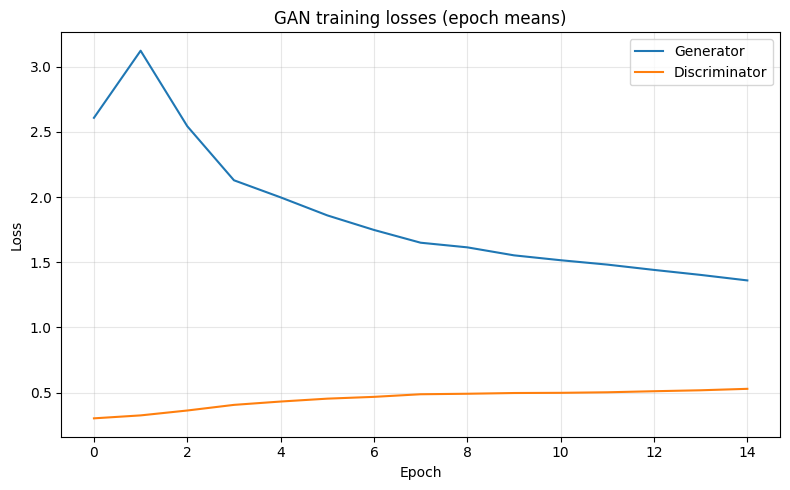

Epoch [16/25]  Loss_G: 1.3408  Loss_D: 0.5315
Epoch [17/25]  Loss_G: 1.3445  Loss_D: 0.5340
Epoch [18/25]  Loss_G: 1.3116  Loss_D: 0.5416
Epoch [19/25]  Loss_G: 1.2968  Loss_D: 0.5402
Epoch [20/25]  Loss_G: 1.2966  Loss_D: 0.5410


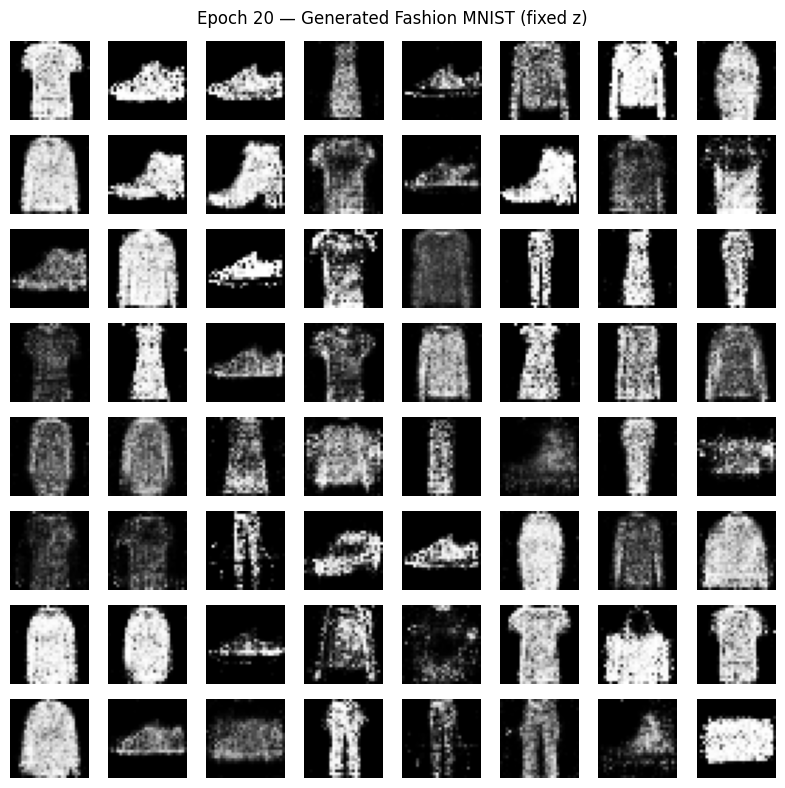

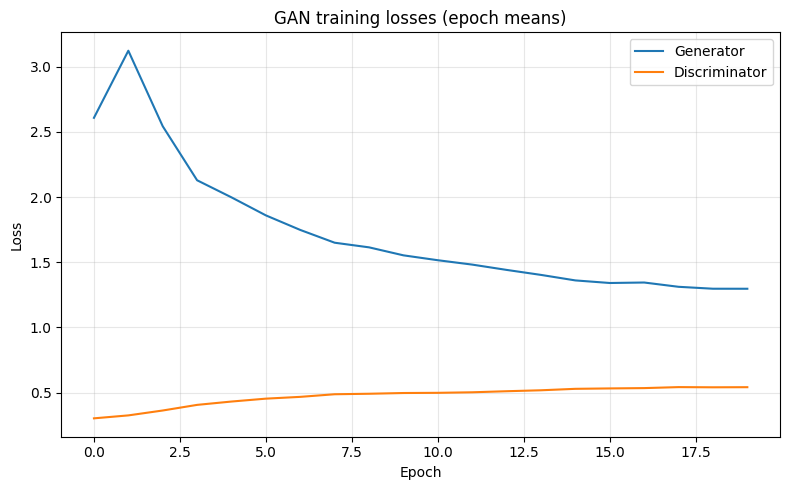

Epoch [21/25]  Loss_G: 1.2836  Loss_D: 0.5449
Epoch [22/25]  Loss_G: 1.2930  Loss_D: 0.5451
Epoch [23/25]  Loss_G: 1.3063  Loss_D: 0.5385
Epoch [24/25]  Loss_G: 1.3038  Loss_D: 0.5406
Epoch [25/25]  Loss_G: 1.3026  Loss_D: 0.5400


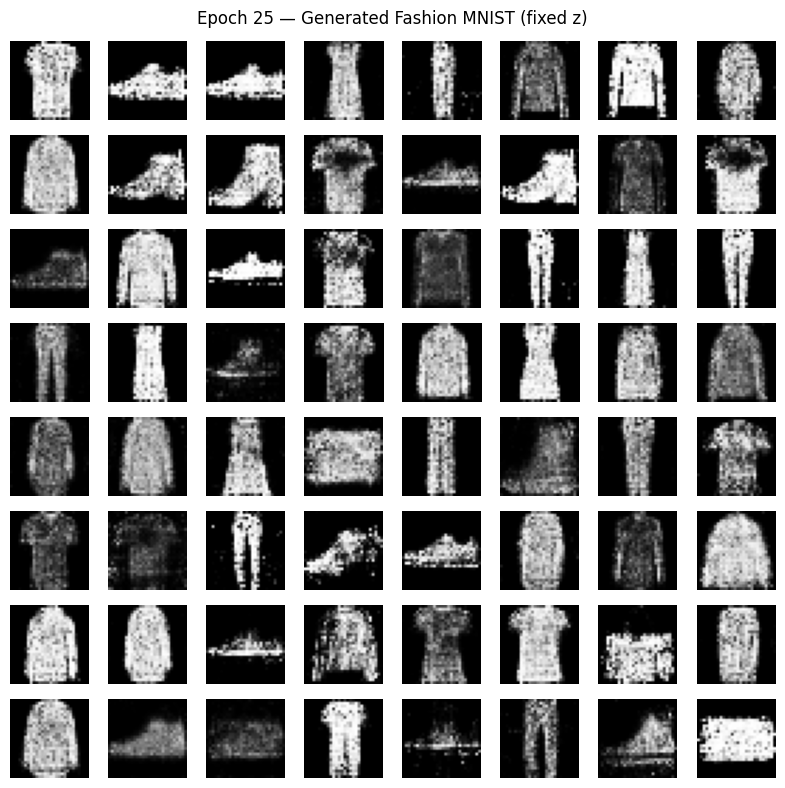

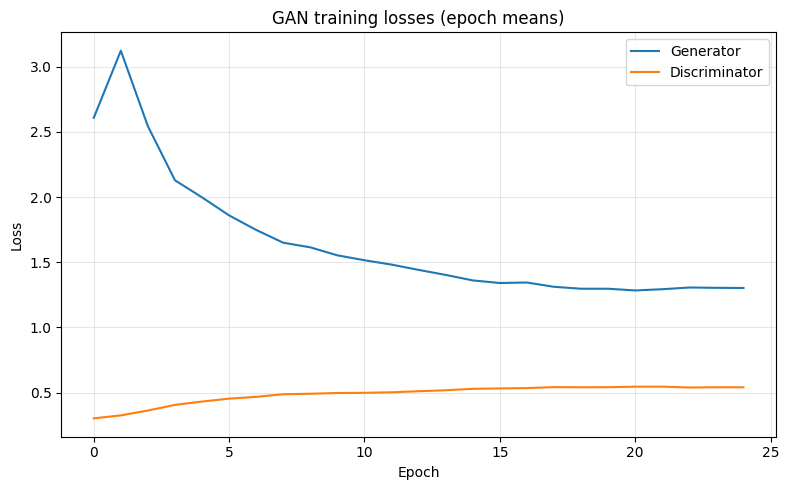

In [13]:
from torch.optim import optimizer
# TODO Task 2: FashionMNIST DataLoader + train + plot real grid + plot fake grid.

train1_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader_fashion = DataLoader(train1_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f'Fashion train sample: {len(train1_dataset)}')
print(f'Fashion train loader: {len(train_loader_fashion)}')

#
G_f = Generator(nz).to(device)
D_f = Discriminator().to(device)
G_f.apply(weights_init)
D_f.apply(weights_init)

# Initialize optimizers for G_f and D_f
optimizerD_f = optim.Adam(D_f.parameters(), lr=lr, betas=betas)
optimizerG_f = optim.Adam(G_f.parameters(), lr=lr, betas=betas)

EPOCHS_fashion=25

loss_G_hist_fashion = []
loss_D_hist_fashion = []

fixed_z = torch.randn(64, nz, device=device)

for epoch in range(1, EPOCHS_fashion + 1):
    G_f.train()
    D_f.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0
    for real_images, _ in train_loader_fashion:
        real_images = real_images.to(device)
        bsz = real_images.size(0)
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        # =====================
        # (1) Update Discriminator
        # =====================
        optimizerD_f.zero_grad(set_to_none=True)
        out_real = D_f(real_images)
        loss_real = criterion(out_real, real_labels)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G_f(z).detach()
        out_fake = D_f(fake_images)
        loss_fake = criterion(out_fake, fake_labels)
        loss_D = (loss_real + loss_fake) / 2.0
        loss_D.backward()
        optimizerD_f.step()

        # =====================
        # (2) Update Generator
        # =====================
        optimizerG_f.zero_grad(set_to_none=True)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G_f(z)
        out_fake_for_G = D_f(fake_images)
        loss_G = criterion(out_fake_for_G, real_labels)
        loss_G.backward()
        optimizerG_f.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1
    loss_G_hist_fashion.append(epoch_g_loss / num_batches)
    loss_D_hist_fashion.append(epoch_d_loss / num_batches)
    print(f'Epoch [{epoch:02d}/{EPOCHS_fashion}]  Loss_G: {loss_G_hist_fashion[-1]:.4f}  Loss_D: {loss_D_hist_fashion[-1]:.4f}')
    if epoch % 5 == 0 or epoch == 1:
        G_f.eval()
        with torch.no_grad():
            fakes = G_f(fixed_z).cpu().view(64, 28, 28)
            fakes = denormalize_to_01(fakes.clamp(-1, 1))
        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flatten()):
              ax.imshow(fakes[i], cmap='gray', vmin=0, vmax=1)
              ax.axis('off')
        plt.suptitle(f'Epoch {epoch} — Generated Fashion MNIST (fixed z)')
        plt.tight_layout()
        plt.show()
        G_f.train()
        plt.figure(figsize=(8, 5))
        plt.plot(loss_G_hist_fashion, label='Generator')
        plt.plot(loss_D_hist_fashion, label='Discriminator')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('GAN training losses (epoch means)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

After 25 epochs, the generator likely produces images that show some general shapes and textures of clothing items, but often with a significant amount of blur and noise,and few shapes as soccer or t-shirt and dresses are recognisible.
Compared to MNIST digits, its images are less clear and difficult to recognise, maybe reason are few epochs and simple GAN strugle its shapes

**Grading (15 pts):** Correct dataset + training ran + two grids + two sentences.


## Task 3 — Compare two learning rates (20 points)

**What to do:** Train the **tutorial GAN twice**, everything the same except **learning rate**:

- **Run A:** `lr = 0.0002` (same as the tutorial).
- **Run B:** `lr = 0.0005` **or** `lr = 0.0001` (pick one).

Use `set_seed(42)` at the **start of each run** so results are comparable. Use the **same** number of epochs for both (e.g. **20** epochs is enough if 50 is slow).

**Hand in:**

1. **One** plot with **both** generator loss curves (`plt.plot` twice + `legend`).
2. **Print** the **last** generator loss for Run A and Run B.
3. Two or three sentences: Which run produced **clearer** digits in your grids (if any)?


**Reminder:** Re-create `G` and `D` (and optimizers) before each run so you start from fresh weights.


Epoch [01/25]  Loss_G: 1.8058  Loss_D: 0.3556
Epoch [01/25]  Loss_G: 1.7877  Loss_D: 0.3958
Epoch [02/25]  Loss_G: 1.6822  Loss_D: 0.3663
Epoch [02/25]  Loss_G: 1.6244  Loss_D: 0.4243
Epoch [03/25]  Loss_G: 1.6582  Loss_D: 0.3783
Epoch [03/25]  Loss_G: 1.5420  Loss_D: 0.4615
Epoch [04/25]  Loss_G: 1.5988  Loss_D: 0.3936
Epoch [04/25]  Loss_G: 1.6037  Loss_D: 0.4256
Epoch [05/25]  Loss_G: 1.5870  Loss_D: 0.3900
Epoch [05/25]  Loss_G: 1.5842  Loss_D: 0.4269
Epoch [06/25]  Loss_G: 1.5573  Loss_D: 0.3984
Epoch [06/25]  Loss_G: 1.5706  Loss_D: 0.4292
Epoch [07/25]  Loss_G: 1.5328  Loss_D: 0.4028
Epoch [07/25]  Loss_G: 1.5462  Loss_D: 0.4344
Epoch [08/25]  Loss_G: 1.5245  Loss_D: 0.4066
Epoch [08/25]  Loss_G: 1.5204  Loss_D: 0.4403
Epoch [09/25]  Loss_G: 1.5045  Loss_D: 0.4070
Epoch [09/25]  Loss_G: 1.5181  Loss_D: 0.4405
Epoch [10/25]  Loss_G: 1.4959  Loss_D: 0.4131
Epoch [10/25]  Loss_G: 1.5145  Loss_D: 0.4408
Epoch [11/25]  Loss_G: 1.4829  Loss_D: 0.4157
Epoch [11/25]  Loss_G: 1.4625  Los

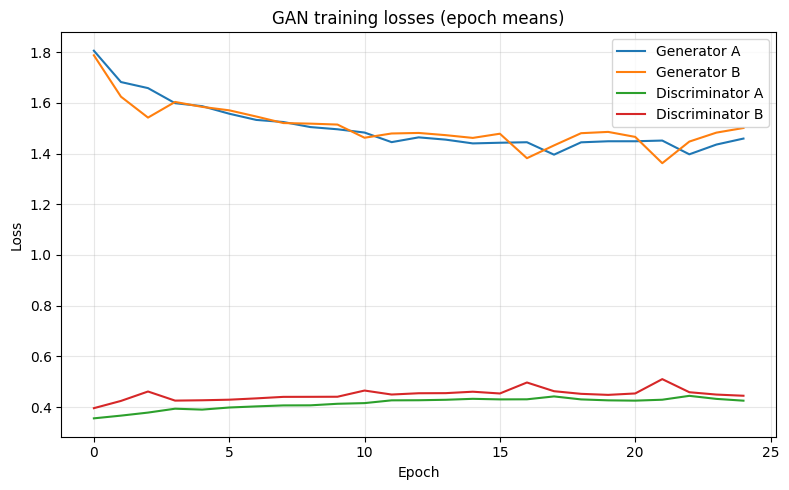

Final loss G A: 1.4592
Final loss G B: 1.5009


In [15]:
# TODO Task 3: Train twice (two learning rates), plot both G losses, print final losses.

lr_A=0.0002
optimizerD_A = optim.Adam(D.parameters(), lr=lr_A, betas=betas)
optimizerG_A = optim.Adam(G.parameters(), lr=lr_A, betas=betas)

lr_B=0.0005
optimizerD_B = optim.Adam(D.parameters(), lr=lr_B, betas=betas)
optimizerG_B = optim.Adam(G.parameters(), lr=lr_B, betas=betas)

num_epochs=25

loss_G_hist_A = []
loss_D_hist_A = []

loss_G_hist_B = []
loss_D_hist_B = []

fixed_z = torch.randn(64, nz, device=device)
for epoch in range(1, num_epochs + 1):
  G.train()
  D.train()
  epoch_g_loss = 0.0
  epoch_d_loss = 0.0
  num_batches = 0
  for real_images, _ in train_loader:
    real_images = real_images.to(device)
    bsz = real_images.size(0)
    real_labels = torch.ones(bsz, 1, device=device)
    fake_labels = torch.zeros(bsz, 1, device=device)
    optimizerD_A.zero_grad(set_to_none=True)
    out_real = D(real_images)
    loss_real = criterion(out_real, real_labels)
    z = torch.randn(bsz, nz, device=device)
    fake_images = G(z).detach()
    out_fake = D(fake_images)
    loss_fake = criterion(out_fake, fake_labels)
    loss_D = (loss_real + loss_fake) / 2.0
    loss_D.backward()
    optimizerD_A.step()
    optimizerG_A.zero_grad(set_to_none=True)
    z = torch.randn(bsz, nz, device=device)
    fake_images = G(z)
    out_fake_for_G = D(fake_images)
    loss_G = criterion(out_fake_for_G, real_labels)
    loss_G.backward()
    optimizerG_A.step()
    epoch_g_loss += loss_G.item()
    epoch_d_loss += loss_D.item()
    num_batches += 1
  loss_G_hist_A.append(epoch_g_loss / num_batches)
  loss_D_hist_A.append(epoch_d_loss / num_batches)
  print(f'Epoch [{epoch:02d}/{num_epochs}]  Loss_G: {loss_G_hist_A[-1]:.4f}  Loss_D: {loss_D_hist_A[-1]:.4f}')
  for real_images, _ in train_loader:
    real_images = real_images.to(device)
    bsz = real_images.size(0)
    real_labels = torch.ones(bsz, 1, device=device)
    fake_labels = torch.zeros(bsz, 1, device=device)
    optimizerD_B.zero_grad(set_to_none=True)
    out_real = D(real_images)
    loss_real = criterion(out_real, real_labels)
    z = torch.randn(bsz, nz, device=device)
    fake_images = G(z).detach()
    out_fake = D(fake_images)
    loss_fake = criterion(out_fake, fake_labels)
    loss_D = (loss_real + loss_fake) / 2.0
    loss_D.backward()
    optimizerD_B.step()
    optimizerG_B.zero_grad(set_to_none=True)
    z = torch.randn(bsz, nz, device=device)
    fake_images = G(z)
    out_fake_for_G = D(fake_images)
    loss_G = criterion(out_fake_for_G, real_labels)
    loss_G.backward()
    optimizerG_B.step()
    epoch_g_loss += loss_G.item()
    epoch_d_loss += loss_D.item()
    num_batches += 1
  loss_G_hist_B.append(epoch_g_loss / num_batches)
  loss_D_hist_B.append(epoch_d_loss / num_batches)
  print(f'Epoch [{epoch:02d}/{num_epochs}]  Loss_G: {loss_G_hist_B[-1]:.4f}  Loss_D: {loss_D_hist_B[-1]:.4f}')


plt.figure(figsize=(8, 5))
plt.plot(loss_G_hist_A, label='Generator A')
plt.plot(loss_G_hist_B, label='Generator B')
plt.plot(loss_D_hist_A, label='Discriminator A')
plt.plot(loss_D_hist_B, label='Discriminator B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN training losses (epoch means)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final loss G A: {loss_G_hist_A[-1]:.4f}')
print(f'Final loss G B: {loss_G_hist_B[-1]:.4f}')

Generator A with lr=0.0002 ends with a slightly lower loss (1.4592) by comparing B model with lr=0.0005 (1.5009 loss) and shows a smoother, more stable trend. Its discriminator loss is also a bit lower and steadier, suggesting a better balance between generator and discriminator

**Grading (20 pts):** Two complete runs + one combined loss plot + printed final losses + short comment.


## Task 4 — Label smoothing for real images (15 points)

**Idea:** When training the **discriminator**, instead of telling it that **every real image** has label **1.0**, use a slightly smaller label, e.g. **0.9**. Fake images still use label **0**. This is called **one-sided label smoothing** and can make training a bit steadier.

**What to do:** Copy the training loop. Where you create `real_labels`, use **`torch.ones(...) * 0.9`** instead of **`torch.ones(...)`**. Train for **at least 25 epochs**.

**Hand in:**

1. Show **one** figure: either **generator loss** over epochs **or** an **8×8 grid** of generated images at the end.
2. Two or three sentences: Did training **feel** more stable (loss jumping less), or did images look **better/worse** than the tutorial? (It is OK if you see little difference.)


**Note:** Keep targets strictly between **0** and **1** (e.g. **0.9** for real, **0** for fake works with `BCELoss`).


Epoch [01/25]  Loss_G: 1.4244  Loss_D: 0.4904
Epoch [02/25]  Loss_G: 1.4212  Loss_D: 0.4872
Epoch [03/25]  Loss_G: 1.4317  Loss_D: 0.4877
Epoch [04/25]  Loss_G: 1.4457  Loss_D: 0.4848
Epoch [05/25]  Loss_G: 1.4499  Loss_D: 0.4847
Epoch [06/25]  Loss_G: 1.4674  Loss_D: 0.4840
Epoch [07/25]  Loss_G: 1.4623  Loss_D: 0.4856
Epoch [08/25]  Loss_G: 1.4703  Loss_D: 0.4832
Epoch [09/25]  Loss_G: 1.4769  Loss_D: 0.4826
Epoch [10/25]  Loss_G: 1.4844  Loss_D: 0.4818
Epoch [11/25]  Loss_G: 1.4906  Loss_D: 0.4803
Epoch [12/25]  Loss_G: 1.4985  Loss_D: 0.4811
Epoch [13/25]  Loss_G: 1.5014  Loss_D: 0.4776
Epoch [14/25]  Loss_G: 1.5103  Loss_D: 0.4767
Epoch [15/25]  Loss_G: 1.5148  Loss_D: 0.4780
Epoch [16/25]  Loss_G: 1.5218  Loss_D: 0.4752
Epoch [17/25]  Loss_G: 1.5330  Loss_D: 0.4736
Epoch [18/25]  Loss_G: 1.5461  Loss_D: 0.4722
Epoch [19/25]  Loss_G: 1.5409  Loss_D: 0.4718
Epoch [20/25]  Loss_G: 1.5505  Loss_D: 0.4701
Epoch [21/25]  Loss_G: 1.5551  Loss_D: 0.4691
Epoch [22/25]  Loss_G: 1.5660  Los

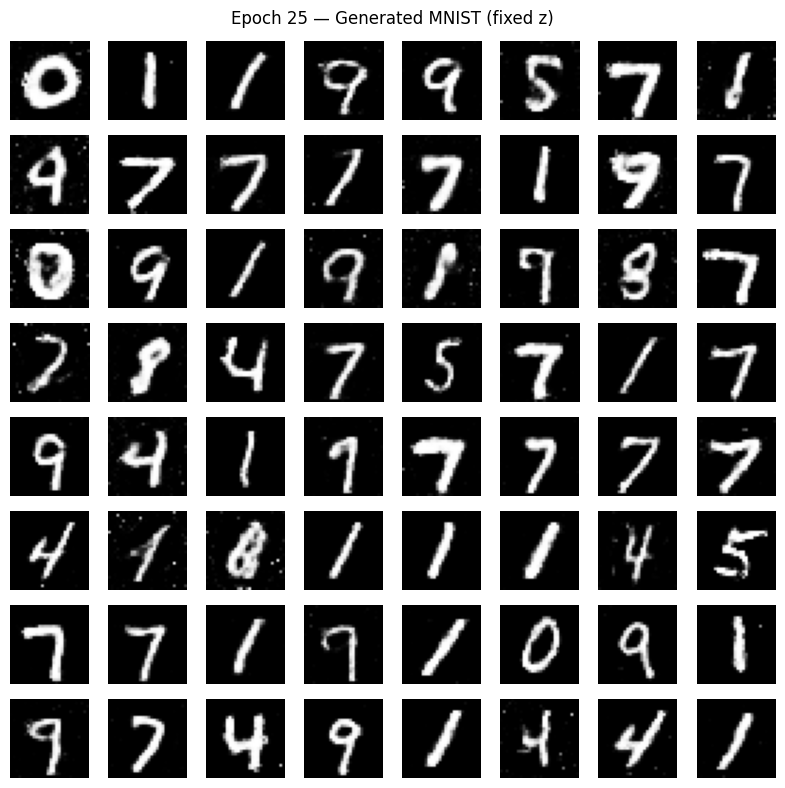

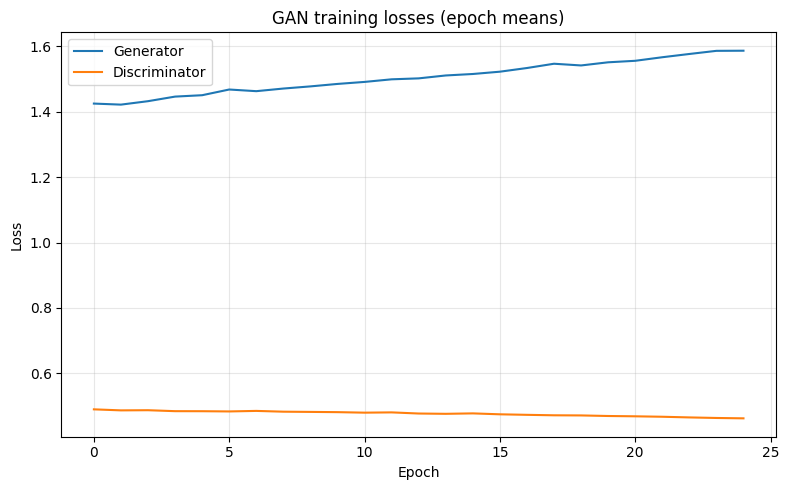

In [16]:
# TODO Task 4: Train with real_labels = 0.9 for D on real batch; plot loss or sample grid.
num_epochs = 25

loss_G_hist = []
loss_D_hist = []

fixed_z = torch.randn(64, nz, device=device)  # same noise for comparable snapshots

for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        bsz = real_images.size(0)

        # --- Labels ---
        real_labels = torch.ones(bsz, 1, device=device)*0.9
        fake_labels = torch.zeros(bsz, 1, device=device)

        # Optional mild label smoothing for real labels (D only) — uncomment to experiment:
        # label_smooth = 0.1
        # real_labels = real_labels * (1.0 - label_smooth) + 0.5 * label_smooth

        # =====================
        # (1) Update Discriminator
        # =====================
        optimizerD.zero_grad(set_to_none=True)

        # Real batch
        out_real = D(real_images)
        loss_real = criterion(out_real, real_labels)

        # Fake batch
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z).detach()
        out_fake = D(fake_images)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = (loss_real + loss_fake) / 2.0
        loss_D.backward()
        optimizerD.step()

        # =====================
        # (2) Update Generator
        # =====================
        optimizerG.zero_grad(set_to_none=True)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z)
        out_fake_for_G = D(fake_images)
        loss_G = criterion(out_fake_for_G, real_labels)  # want D(fake) ~ 1
        loss_G.backward()
        optimizerG.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1

    loss_G_hist.append(epoch_g_loss / num_batches)
    loss_D_hist.append(epoch_d_loss / num_batches)

    print(f"Epoch [{epoch:02d}/{num_epochs}]  Loss_G: {loss_G_hist[-1]:.4f}  Loss_D: {loss_D_hist[-1]:.4f}")


G.eval()
with torch.no_grad():
            fakes = G(fixed_z).cpu().view(64, 28, 28)
            fakes = denormalize_to_01(fakes.clamp(-1, 1))
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
            ax.imshow(fakes[i], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
plt.suptitle(f'Epoch {epoch} — Generated MNIST (fixed z)')
plt.tight_layout()
plt.show()
G.train()
plt.figure(figsize=(8, 5))
plt.plot(loss_G_hist, label='Generator')
plt.plot(loss_D_hist, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN training losses (epoch means)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


it shows progression with no blurring affect  and without big jump or rapid changing in Generator and Discriminator.

**Grading (15 pts):** Code runs + one figure + short written reflection.


---

# Bonus: Theoretical Questions (10% extra credit)


**Question 1 — Mode collapse:** In your own words, what is **mode collapse**? Give **one** reason it can happen and **one** idea to reduce it.

**Question 2 — Generator loss:** In this lab, the generator is trained so that **fake** images are labeled like **real** ones for the discriminator. What goes wrong if the discriminator becomes **too good** at spotting fakes early in training?

**Question 3 — Why two networks?** Why do we need **both** a generator and a discriminator? What would happen if we only trained a generator with a simple pixel-wise loss to match MNIST images?


### Your answers

**Double-click** this cell and write your answers under each heading.

#### Q1 — Mode collapse

*Model collapse is failure in generative AI  where model stops producing diverse, varied outputs and instead it collapsed by generating same one or few results over and over again.
It occurs when generator finds a specific, narrow type of output that the discriminator struggles to classify as fake and can be avoided by different loss function or modify architecture *

#### Q2 — Vanishing gradients

*If the discriminator becomes too good at spotting fakes early in GAN training, the generator will stop learning and fail of training process.*

#### Q3 — Why two networks?

*It requires both generator and discriminator due to that generator creates fakes, while the discriminator acts as an intelligent, evolving critic that teaches the generator to make realistic, high-quality images. Without the discriminator, a generator trained only with pixel-wise loss  produces blurry, average, or unconvincing MNIST images because it focuses on getting pixel colors right on average rather than creating sharp, realistic structure*
